# Transformer-Based Sentiment Analysis of Arabic Tweets

## An Egyptian-Focused Comparative Study

**Task:** Three-class Arabic tweet sentiment classification (Negative, Neutral, Positive)  
**Study Design:** Egyptian-focused, but not Egyptian-only  
**Stage I:** ASTD-only controlled experiments  
**Stage II:** Quality-filtered combined ASTD–ArSAS evaluation  
**Classical Baseline:** Character TF–IDF with class-balanced logistic regression  
**Transformer Baseline:** Standard AraBERTv02 on raw tweets with standard cross-entropy  
**Proposed System:** AraBERTv02-Twitter on controlled preprocessed tweets with class-weighted focal loss and validation-selected learning rate  
**Extension:** Within-seed raw-logit ensemble  
**Primary Metric:** Macro F1  
**Robustness Protocol:** Fixed leakage-checked 80/10/10 split and three training seeds (21, 42, 77)

This notebook implements a reproducible two-stage experimental pipeline. Stage I evaluates preprocessing, class balancing, training duration, data augmentation, and pretrained encoder selection using ASTD. Stage II compares the classical baseline, standard AraBERTv02, the proposed Twitter-adapted AraBERT system, and a raw-logit ensemble on the same fixed combined test partition.

ArSAS is used as an auxiliary multi-source Arabic Twitter corpus and is not treated as a Saudi-dialect comparison group. Final Stage II conclusions are based on the multi-seed mean ± standard deviation rather than the most favorable individual run.

> **Scientific note:** The Stage II baseline and proposed systems differ simultaneously in checkpoint, input representation, loss function, and learning rate. Therefore, their comparison evaluates two complete systems and does not isolate the causal contribution of any single component.

In [1]:
# Install project packages only — do not reinstall torch, numpy, scipy, or scikit-learn
!pip -q install -U "transformers>=4.46,<6" "accelerate>=0.34,<2" sentencepiece arabic-reshaper python-bidi "gradio>=4.44,<6"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.6/325.6 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 40.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hf-gradio 0.4.1 requires gradio-c

In [2]:
import os, re, gc, json, random, hashlib, warnings, platform
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42  # fixed data-split and tuning seed
RUN_SEEDS = [21, 42, 77]  # independent training replications
CONFIDENCE_THRESHOLD = 0.75  # raised from 0.60 to cut ArSAS label noise
MAX_LENGTH = 128
EPOCHS = 5
BATCH_SIZE = 16  # Safe for Colab T4; use 32 if memory permits
GRAD_ACCUM_STEPS = 2  # Effective batch size = 32
LEARNING_RATE = 2e-5
FOCAL_GAMMA = 2.0  # focusing parameter for Focal Loss
OUTPUT_ROOT = Path("GP_Results")
FIG_DIR = OUTPUT_ROOT / "figures"
MODEL_DIR = OUTPUT_ROOT / "models"
TABLE_DIR = OUTPUT_ROOT / "tables"
for p in [FIG_DIR, MODEL_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()
assert torch.cuda.is_available(), "Enable a T4 GPU: Runtime -> Change runtime type"
print("CUDA kernel smoke test: PASSED")

CUDA kernel smoke test: PASSED


## 2. Load ASTD and ArSAS

ASTD is downloaded from its official public repository. Upload the supplied
**ArSAS.txt** (the filename may include a suffix such as `ArSAS(1).txt`; the
code handles it automatically).


In [3]:
ASTD_URL = "https://raw.githubusercontent.com/mahmoudnabil/ASTD/master/data/Tweets.txt"
astd_raw = pd.read_csv(
    ASTD_URL, sep="\t", header=None, names=["tweet", "label_raw"], encoding="utf-8"
)
print("ASTD loaded:", astd_raw.shape)

from google.colab import files

print("Upload ArSAS.txt now")
uploaded = files.upload()
arsas_candidates = [
    name
    for name in uploaded
    if "arsas" in name.lower() and name.lower().endswith(".txt")
]
assert arsas_candidates, "No ArSAS .txt file was detected."
ARSAS_PATH = arsas_candidates[0]
arsas_raw = pd.read_csv(ARSAS_PATH, sep="\t", encoding="utf-8")
print("ArSAS loaded:", arsas_raw.shape, "from", ARSAS_PATH)

ASTD loaded: (9694, 2)
Upload ArSAS.txt now


Saving ArSAS (2).txt to ArSAS (2).txt
ArSAS loaded: (19897, 7) from ArSAS (2).txt


## 3. Label Harmonization and Quality Filtering

- ASTD `OBJ` is excluded because objective is not identical to neutral sentiment.
- ArSAS `Mixed` is excluded because the target task has three classes.
- ArSAS labels with confidence below **0.75** are excluded (raised from 0.60 to
  reduce annotation noise — this is the single highest-leverage data change).
- Empty texts, exact duplicates, normalized duplicates, and conflicting labels
  are handled before splitting.


In [4]:
print("ASTD original labels:\n", astd_raw["label_raw"].value_counts(dropna=False))
print(
    "\nArSAS original labels:\n",
    arsas_raw["Sentiment_label"].value_counts(dropna=False),
)

astd_map = {"NEG": "Negative", "NEUTRAL": "Neutral", "POS": "Positive"}
astd = astd_raw[astd_raw["label_raw"].isin(astd_map)].copy()
astd["sentiment"] = astd["label_raw"].map(astd_map)
astd["source"] = "ASTD"
astd["confidence"] = 1.0
astd = astd[["tweet", "sentiment", "source", "confidence"]]

required = {"Tweet_text", "Sentiment_label", "Sentiment_label_confidence"}
assert required.issubset(
    arsas_raw.columns
), f"Missing ArSAS columns: {required-set(arsas_raw.columns)}"
arsas = arsas_raw[
    arsas_raw["Sentiment_label"].isin(["Negative", "Neutral", "Positive"])
    & (
        pd.to_numeric(arsas_raw["Sentiment_label_confidence"], errors="coerce")
        >= CONFIDENCE_THRESHOLD
    )
].copy()
arsas = arsas.rename(
    columns={
        "Tweet_text": "tweet",
        "Sentiment_label": "sentiment",
        "Sentiment_label_confidence": "confidence",
    }
)
arsas["source"] = "ArSAS"
arsas = arsas[["tweet", "sentiment", "source", "confidence"]]

df = pd.concat([astd, arsas], ignore_index=True)
df["tweet"] = df["tweet"].astype("string").str.strip()
df = df[df["tweet"].notna() & df["tweet"].ne("")].copy()
print("After label harmonization:", df.shape)
print(pd.crosstab(df["source"], df["sentiment"], margins=True))

ASTD original labels:
 label_raw
OBJ        6470
NEG        1642
NEUTRAL     805
POS         777
Name: count, dtype: int64

ArSAS original labels:
 Sentiment_label
Negative    7384
Neutral     6894
Positive    4400
Mixed       1219
Name: count, dtype: int64
After label harmonization: (13968, 4)
sentiment  Negative  Neutral  Positive    All
source                                       
ASTD           1642      805       777   3224
ArSAS          4271     4268      2205  10744
All            5913     5073      2982  13968


In [5]:
AR_DIACRITICS = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u06D6-\u06ED]")


def comparison_key(text):
    """Aggressive normalization used ONLY to detect duplicates; never used as model input."""
    text = str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@[A-Za-z0-9_]+", " USER ", text)
    text = AR_DIACRITICS.sub("", text)
    text = re.sub(r"ـ+", "", text)
    text = re.sub("[إأآٱ]", "ا", text).replace("ى", "ي")
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


quality = {
    "rows_after_filtering": len(df),
    "exact_duplicate_rows": int(df.duplicated(["tweet", "sentiment"]).sum()),
}
df = df.drop_duplicates(["tweet", "sentiment"]).copy()
df["comparison_key"] = df["tweet"].map(comparison_key)

conflict_keys = df.groupby("comparison_key")["sentiment"].nunique()
conflict_keys = set(conflict_keys[conflict_keys > 1].index)
quality["conflicting_normalized_texts_removed"] = len(conflict_keys)
df = df[~df["comparison_key"].isin(conflict_keys)].copy()

# Prefer higher-confidence ArSAS annotation when normalized duplicates remain.
df = (
    df.sort_values(["confidence", "source"], ascending=[False, True])
    .drop_duplicates("comparison_key", keep="first")
    .reset_index(drop=True)
)
quality["final_unique_rows"] = len(df)
print(json.dumps(quality, indent=2))
print(
    "\nFinal source × label table:\n",
    pd.crosstab(df.source, df.sentiment, margins=True),
)

{
  "rows_after_filtering": 13968,
  "exact_duplicate_rows": 42,
  "conflicting_normalized_texts_removed": 1,
  "final_unique_rows": 13915
}

Final source × label table:
 sentiment  Negative  Neutral  Positive    All
source                                       
ASTD           1641      805       776   3222
ArSAS          4239     4257      2197  10693
All            5880     5062      2973  13915


## 4. Controlled Arabic Tweet Preprocessing

The pipeline intentionally preserves emojis, Arabic hashtags, negation words,
and stop words. It does not use stemming or lemmatization. URLs and mentions
are replaced with semantic placeholders; diacritics and tatweel are removed;
whitespace and common letter variants are normalized.


In [6]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@[A-Za-z0-9_]+")


def preprocess_arabic_tweet(text):
    text = str(text)
    text = URL_RE.sub(" رابط ", text)
    text = MENTION_RE.sub(" مستخدم ", text)
    text = AR_DIACRITICS.sub("", text)
    text = re.sub(r"ـ+", "", text)
    text = re.sub("[إأآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # reduce 3+ repetitions to 2
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["raw_tweet"] = df["tweet"].astype(str)
df["clean_tweet"] = df["raw_tweet"].map(preprocess_arabic_tweet)
df = df[df["clean_tweet"].str.len() >= 2].reset_index(drop=True)
print(
    df[["raw_tweet", "clean_tweet", "sentiment", "source"]]
    .sample(8, random_state=SEED)
    .to_string(index=False)
)

                                                                                                                                                                                                 raw_tweet                                                                                                                                                          clean_tweet sentiment source
                                                                                                                     اهداف مباراة مصر وغانا 1 1 شاشة كاملة تصفيات كاس العالم 2018: https://t.co/MiBvFUNLBW                                                                                                   اهداف مباراة مصر وغانا 1 1 شاشة كاملة تصفيات كاس العالم 2018: رابط   Neutral  ArSAS
                                                                    #لايف.. مباراة #مصر و #غانا اليوم الأحد 12-11-2017 تصفيات #كأس_العالم 2018 شاهد من هنا◄https://t.co/BmIMx1IxK9 https://t.co/ed1lqqg69a                            

## 5. Exploratory Data Analysis and Publication-Quality Figures

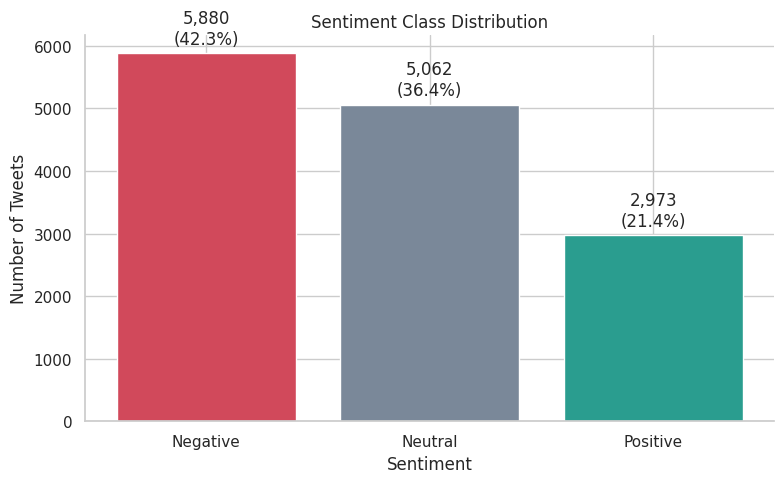

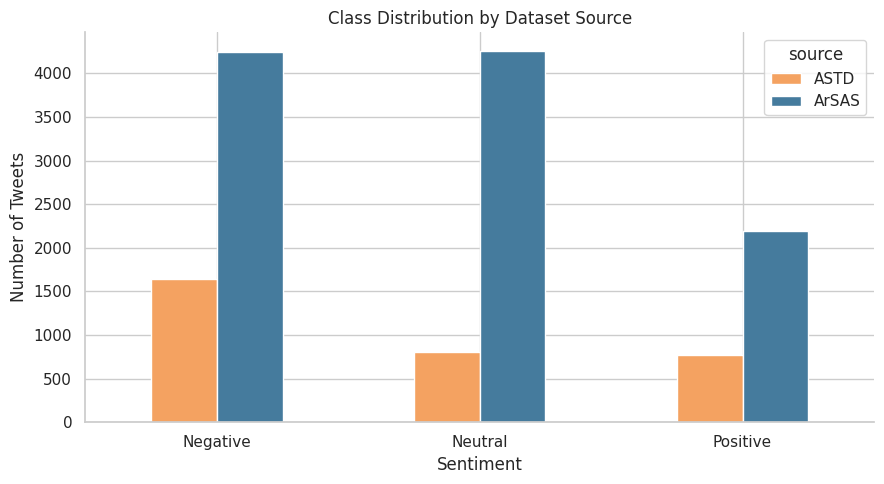

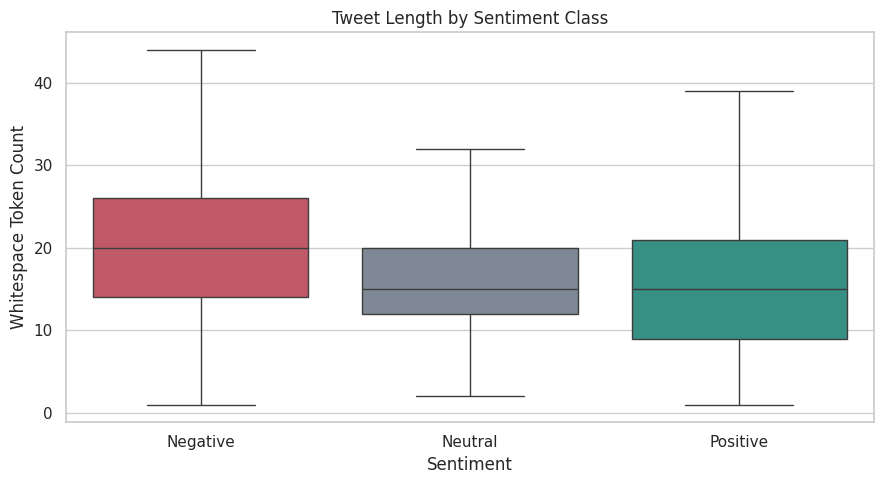

,count,mean,std,min,50%,max
sentiment,,,,,,
Negative,5880.0,22.29,23.60,1.0,20.0,1042.0
Neutral,5062.0,17.32,21.25,2.0,15.0,880.0
Positive,2973.0,17.77,42.96,1.0,15.0,1733.0


In [7]:
label_order = ["Negative", "Neutral", "Positive"]
palette = {"Negative": "#D1495B", "Neutral": "#7A8899", "Positive": "#2A9D8F"}

counts = df["sentiment"].value_counts().reindex(label_order)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=[palette[x] for x in label_order])
ax.bar_label(bars, labels=[f"{v:,}\n({v/len(df):.1%})" for v in counts], padding=4)
ax.set(
    title="Sentiment Class Distribution", xlabel="Sentiment", ylabel="Number of Tweets"
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

cross = pd.crosstab(df.sentiment, df.source).reindex(label_order)
ax = cross.plot(kind="bar", figsize=(9, 5), color=["#F4A261", "#457B9D"])
ax.set(
    title="Class Distribution by Dataset Source",
    xlabel="Sentiment",
    ylabel="Number of Tweets",
)
ax.tick_params(axis="x", rotation=0)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_distribution_by_source.png", dpi=300, bbox_inches="tight")
plt.show()

df["token_count"] = df.clean_tweet.str.split().str.len()
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="sentiment",
    y="token_count",
    order=label_order,
    palette=palette,
    showfliers=False,
)
plt.title("Tweet Length by Sentiment Class")
plt.xlabel("Sentiment")
plt.ylabel("Whitespace Token Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_length_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

summary = df.groupby("sentiment")["token_count"].describe()[
    ["count", "mean", "std", "min", "50%", "max"]
]
display(summary.round(2))
summary.to_csv(TABLE_DIR / "length_summary.csv")

## 6. Fixed Stratified Train/Validation/Test Split

The same 80/10/10 split is reused by all models. Duplicate removal occurs
before splitting. The test set is not used for model selection.


In [8]:
label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {v: k for k, v in label2id.items()}
df["label"] = df.sentiment.map(label2id).astype(int)

df["stratum"] = df["label"].astype(str) + "__" + df["source"]
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df["stratum"]
)
temp_df = temp_df.copy()
temp_df["stratum"] = temp_df["label"].astype(str) + "__" + temp_df["source"]
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["stratum"]
)

for split in [train_df, val_df, test_df]:
    split.reset_index(drop=True, inplace=True)
assert not set(train_df.comparison_key) & set(val_df.comparison_key)
assert not set(train_df.comparison_key) & set(test_df.comparison_key)
assert not set(val_df.comparison_key) & set(test_df.comparison_key)
print("Normalized text overlap across splits: 0 — PASSED")

split_table = pd.concat(
    {
        "Train": train_df.sentiment.value_counts(),
        "Validation": val_df.sentiment.value_counts(),
        "Test": test_df.sentiment.value_counts(),
    },
    axis=1,
).reindex(label_order)
split_table.loc["Total"] = split_table.sum()
display(split_table)
split_table.to_csv(TABLE_DIR / "split_distribution.csv")

manifest = {
    "seed": SEED,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "split": "80/10/10 stratified by label and source",
    "final_rows": len(df),
    "train": len(train_df),
    "validation": len(val_df),
    "test": len(test_df),
}
Path(TABLE_DIR / "manifest.json").write_text(
    json.dumps(manifest, indent=2), encoding="utf-8"
)
print(json.dumps(manifest, indent=2))

Normalized text overlap across splits: 0 — PASSED


,Train,Validation,Test
sentiment,,,
Negative,4704,588,588
Neutral,4050,505,507
Positive,2378,298,297
Total,11132,1391,1392


{
  "seed": 42,
  "confidence_threshold": 0.75,
  "split": "80/10/10 stratified by label and source",
  "final_rows": 13915,
  "train": 11132,
  "validation": 1391,
  "test": 1392
}


## 6.1 Leakage-Safe Egyptian-Only Evaluation Slice

The Egyptian-only evaluation uses only ASTD rows already assigned to the fixed
held-out test split. These rows are never used for Stage II training,
validation, or learning-rate selection. This is therefore an **ASTD subset of
the fixed Stage II test split**, not an evaluation on the full ASTD corpus and
not necessarily the same split used by another experimental track.

In [9]:
astd_test_df = test_df.loc[test_df["source"].eq("ASTD")].copy().reset_index(drop=True)

assert len(astd_test_df) > 0, "No ASTD rows were found in the held-out test split."
assert not set(astd_test_df.comparison_key) & set(train_df.comparison_key)
assert not set(astd_test_df.comparison_key) & set(val_df.comparison_key)
assert set(astd_test_df.comparison_key).issubset(set(test_df.comparison_key))

astd_test_distribution = (
    astd_test_df["sentiment"]
    .value_counts()
    .reindex(label_order, fill_value=0)
    .rename_axis("Sentiment")
    .reset_index(name="Count")
)
display(astd_test_distribution)
astd_test_distribution.to_csv(
    TABLE_DIR / "astd_heldout_test_distribution.csv", index=False
)

print(f"Leakage-safe ASTD held-out test rows: {len(astd_test_df):,}")
print("Overlap with Stage II train/validation: 0 — PASSED")

,Sentiment,Count
0,Negative,164
1,Neutral,81
2,Positive,77


Leakage-safe ASTD held-out test rows: 322
Overlap with Stage II train/validation: 0 — PASSED


## 7. Shared Evaluation Framework

This section defines reusable datasets, metrics, focal and weighted loss trainers, training curves, prediction storage, and class-aware evaluation. The focal-loss focusing parameter is fixed before final test evaluation.


In [10]:
from scipy.stats import binomtest
import math

BASELINE_MODEL = "aubmindlab/bert-base-arabertv02"
PROPOSED_MODEL = "aubmindlab/bert-base-arabertv02-twitter"
LR_CANDIDATES = [1e-5, 2e-5, 3e-5]
RESULTS = []
PREDICTIONS = {}
SEARCH_RESULTS = []
HISTORIES = {}
LOGITS = {}


def metrics_dict(y_true, y_pred):
    pm, rm, fm, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    pw, rw, fw, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": pm,
        "recall_macro": rm,
        "f1_macro": fm,
        "f1_weighted": fw,
    }


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return metrics_dict(labels, np.argmax(logits, axis=1))


class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts.astype(str).tolist()
        self.labels = labels.astype(int).tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        x = self.tokenizer(
            self.texts[i], truncation=True, max_length=MAX_LENGTH, padding=False
        )
        x = {k: torch.tensor(v, dtype=torch.long) for k, v in x.items()}
        x["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return x


class FocalLoss(nn.Module):
    """Standard multi-class focal loss with per-class alpha weights."""

    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.register_buffer("alpha", alpha.detach().clone().float())
        self.gamma = float(gamma)

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=-1)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        alpha_t = self.alpha.to(logits.device)[targets]
        loss = -alpha_t * ((1.0 - pt) ** self.gamma) * log_pt
        return loss.mean()


class WeightedTrainer(Trainer):
    """Kept for the baseline system (plain class-weighted cross-entropy)."""

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self, model, inputs, return_outputs=False, num_items_in_batch=None
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.class_weights.to(outputs.logits.device))(
            outputs.logits, labels
        )
        return (loss, outputs) if return_outputs else loss


class FocalTrainer(Trainer):
    """Used for the proposed system: Focal Loss instead of plain weighted CE."""

    def __init__(self, *args, class_weights=None, gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fn = FocalLoss(class_weights, gamma=gamma)

    def compute_loss(
        self, model, inputs, return_outputs=False, num_items_in_batch=None
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = self.loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


class_weights = torch.tensor(
    compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=train_df.label),
    dtype=torch.float,
)
print(
    "Class weights (weighted CE and focal alpha; standard CE stays unweighted):",
    {id2label[i]: round(float(w), 4) for i, w in enumerate(class_weights)},
)


def datasets_for(tokenizer, text_column):
    return (
        TweetDataset(train_df[text_column], train_df.label, tokenizer),
        TweetDataset(val_df[text_column], val_df.label, tokenizer),
        TweetDataset(test_df[text_column], test_df.label, tokenizer),
    )


def plot_history(history, name):
    h = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    if "loss" in h:
        z = h.dropna(subset=["loss"])
        axes[0].plot(z.epoch, z.loss, "o-", label="Training")
    if "eval_loss" in h:
        z = h.dropna(subset=["eval_loss"])
        axes[0].plot(z.epoch, z.eval_loss, "s-", label="Validation")
    axes[0].set(title=f"{name} — Loss", xlabel="Epoch", ylabel="Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.25)
    if "eval_f1_macro" in h:
        z = h.dropna(subset=["eval_f1_macro"])
        axes[1].plot(z.epoch, z.eval_f1_macro, "o-", color="#2A9D8F")
    axes[1].set(
        title=f"{name} — Validation Macro F1",
        xlabel="Epoch",
        ylabel="Macro F1",
        ylim=(0, 1),
    )
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}_curves.png", dpi=300, bbox_inches="tight")
    plt.show()


def record_test(name, output, store_logits=True):
    y = output.label_ids
    logits = output.predictions
    p = np.argmax(logits, axis=1)
    m = metrics_dict(y, p)
    RESULTS.append({"System": name, **m})
    report = classification_report(
        y, p, target_names=label_order, output_dict=True, zero_division=0
    )
    rdf = pd.DataFrame(report).T
    display(rdf.round(4))
    rdf.to_csv(TABLE_DIR / f"{name}_classification_report.csv")
    pdf = pd.DataFrame(
        {
            "text": test_df.raw_tweet.tolist(),
            "source": test_df.source.tolist(),
            "comparison_key": test_df.comparison_key.tolist(),
            "true_id": y,
            "pred_id": p,
        }
    )
    pdf["true_label"] = pdf.true_id.map(id2label)
    pdf["pred_label"] = pdf.pred_id.map(id2label)
    pdf["correct"] = pdf.true_id.eq(pdf.pred_id)
    PREDICTIONS[name] = pdf
    pdf.to_csv(TABLE_DIR / f"{name}_predictions.csv", index=False)
    if store_logits:
        LOGITS[name] = logits
    cm = confusion_matrix(y, p, labels=[0, 1, 2])
    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_order,
        yticklabels=label_order,
    )
    plt.title(f"{name} — Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}_confusion.png", dpi=300, bbox_inches="tight")
    plt.show()


def train_system(
    name,
    model_name,
    text_column,
    lr,
    loss_mode,
    epochs=5,
    evaluate_test=True,
    run_seed=SEED,
):
    """loss_mode: 'plain' (standard CE), 'weighted' (weighted CE), or 'focal' (focal loss)."""
    seed_everything(run_seed)
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )
    tr, va, te = datasets_for(tokenizer, text_column)

    args = TrainingArguments(
        output_dir=str(MODEL_DIR / name),
        seed=run_seed,
        data_seed=run_seed,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=32,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=epochs,
        weight_decay=0.01,
        # warmup_ratio=0.10,
        max_grad_norm=1.0,
        fp16=True,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
    )
    kwargs = {
        "model": model,
        "args": args,
        "train_dataset": tr,
        "eval_dataset": va,
        "data_collator": DataCollatorWithPadding(tokenizer),
        "compute_metrics": compute_metrics,
        "callbacks": [EarlyStoppingCallback(early_stopping_patience=2)],
    }
    if loss_mode == "focal":
        trainer = FocalTrainer(**kwargs, class_weights=class_weights, gamma=FOCAL_GAMMA)
    elif loss_mode == "weighted":
        trainer = WeightedTrainer(**kwargs, class_weights=class_weights)
    else:
        trainer = Trainer(**kwargs)
    trainer.train()
    HISTORIES[name] = trainer.state.log_history
    plot_history(trainer.state.log_history, name)
    print("Validation:", trainer.evaluate(va))
    if evaluate_test:
        record_test(name, trainer.predict(te))
    path = MODEL_DIR / f"{name}_best"
    trainer.save_model(str(path))
    tokenizer.save_pretrained(str(path))
    del trainer, model, tr, va, te
    gc.collect()
    torch.cuda.empty_cache()
    return str(path)

Class weights (weighted CE and focal alpha; standard CE stays unweighted): {'Negative': 0.7888, 'Neutral': 0.9162, 'Positive': 1.5604}


## 7.1 Classical Baseline — TF-IDF + Logistic Regression

This non-transformer baseline uses character-level TF-IDF features and
class-balanced logistic regression. It is trained on the same Stage II training
partition and evaluated on the same fixed combined test split. A second result
is reported on the leakage-safe ASTD-only held-out slice.

In [11]:
CLASSICAL_NAME = "Classical_TFIDF_LogisticRegression"

tfidf_lr = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=2,
                max_features=100_000,
                sublinear_tf=True,
            ),
        ),
        (
            "logistic_regression",
            LogisticRegression(
                C=1.0,
                class_weight="balanced",
                max_iter=2_000,
                random_state=SEED,
                solver="lbfgs",
            ),
        ),
    ]
)

tfidf_lr.fit(train_df["clean_tweet"], train_df["label"])


def evaluate_classical(frame, evaluation_name):
    y_true = frame["label"].to_numpy()
    y_pred = tfidf_lr.predict(frame["clean_tweet"])
    metrics = metrics_dict(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=label_order,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(
        TABLE_DIR / f"{evaluation_name}_classification_report.csv"
    )

    predictions = frame[["raw_tweet", "source", "comparison_key"]].copy()
    predictions["true_id"] = y_true
    predictions["pred_id"] = y_pred
    predictions["true_label"] = predictions["true_id"].map(id2label)
    predictions["pred_label"] = predictions["pred_id"].map(id2label)
    predictions["correct"] = predictions["true_id"].eq(predictions["pred_id"])
    predictions.to_csv(TABLE_DIR / f"{evaluation_name}_predictions.csv", index=False)
    return metrics


classical_combined_metrics = evaluate_classical(test_df, CLASSICAL_NAME)
classical_astd_metrics = evaluate_classical(
    astd_test_df, f"{CLASSICAL_NAME}_ASTD_Heldout"
)

RESULTS.append({"System": CLASSICAL_NAME, **classical_combined_metrics})

classical_results_table = pd.DataFrame(
    [
        {"Evaluation Set": "Combined held-out test", **classical_combined_metrics},
        {"Evaluation Set": "ASTD held-out subset", **classical_astd_metrics},
    ]
)
display(classical_results_table.round(4))
classical_results_table.to_csv(
    TABLE_DIR / "classical_tfidf_logistic_regression_results.csv", index=False
)

,Evaluation Set,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Combined held-out test,0.8147,0.8054,0.8055,0.8042,0.8145
1,ASTD held-out subset,0.5901,0.5088,0.5246,0.4945,0.5445


## 8. Baseline System — Standard AraBERTv02 on Raw Tweets

The baseline uses the general-purpose `aubmindlab/bert-base-arabertv02` checkpoint, raw tweets, standard cross-entropy loss, and a predefined learning rate of `2e-5`.


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

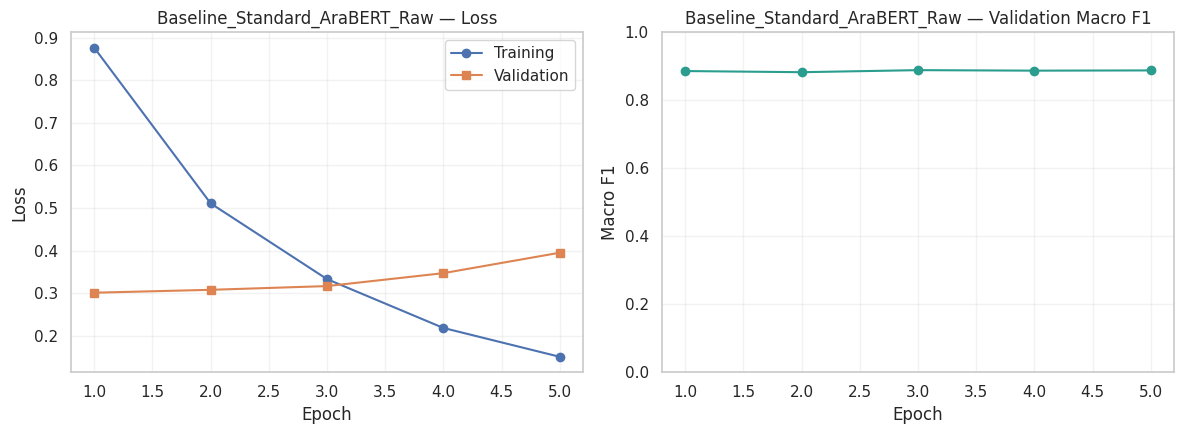

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0.150757,0.316719,5,0.891445,0.885445,0.892818,0.888766,0.891680


Validation: {'eval_loss': 0.3167186975479126, 'eval_accuracy': 0.8914450035945363, 'eval_precision_macro': 0.8854449120294584, 'eval_recall_macro': 0.8928175292532678, 'eval_f1_macro': 0.8887660944536261, 'eval_f1_weighted': 0.8916796504793834}


,precision,recall,f1-score,support
Negative,0.9242,0.8707,0.8967,588.0000
Neutral,0.8791,0.8462,0.8623,507.0000
Positive,0.7657,0.9024,0.8284,297.0000
accuracy,0.8685,0.8685,0.8685,0.8685
macro avg,0.8563,0.8731,0.8625,1392.0000
weighted avg,0.8740,0.8685,0.8696,1392.0000


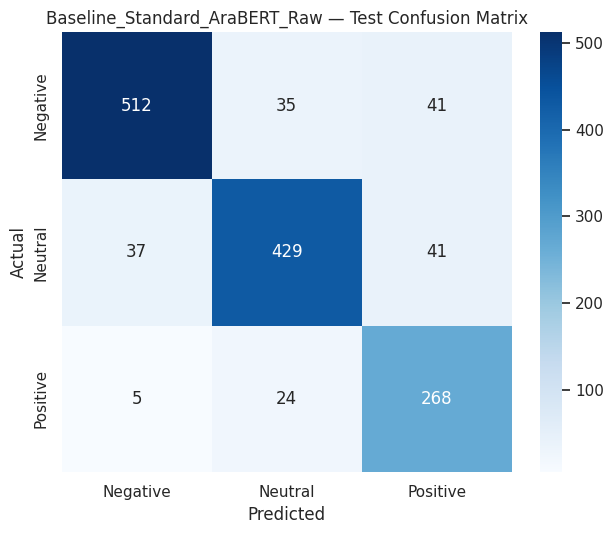

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
baseline_path = train_system(
    "Baseline_Standard_AraBERT_Raw", BASELINE_MODEL, "raw_tweet", 2e-5, "plain", 5, True
)

## 9. Proposed System — Validation-Only Hyperparameter Selection

The proposed system uses `aubmindlab/bert-base-arabertv02-twitter`, controlled preprocessing, and focal loss. Candidate learning rates (`1e-5`, `2e-5`, `3e-5`) are compared using validation Macro F1 only. Search trials never evaluate the test set.


In [13]:
def proposed_search(lr):
    seed_everything()
    name = f"Twitter_AraBERT_Search_{lr}"
    tokenizer = AutoTokenizer.from_pretrained(PROPOSED_MODEL, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        PROPOSED_MODEL,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )
    tr, va, _ = datasets_for(tokenizer, "clean_tweet")

    args = TrainingArguments(
        output_dir=str(MODEL_DIR / name),
        seed=SEED,
        data_seed=SEED,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=32,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=3,
        weight_decay=0.01,
        # warmup_ratio=0.10,
        max_grad_norm=1.0,
        fp16=True,
        report_to="none",
    )
    trainer = FocalTrainer(
        model=model,
        args=args,
        train_dataset=tr,
        eval_dataset=va,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        gamma=FOCAL_GAMMA,
    )
    trainer.train()
    vm = trainer.evaluate(va)
    SEARCH_RESULTS.append(
        {
            "learning_rate": lr,
            "val_accuracy": vm["eval_accuracy"],
            "val_f1_macro": vm["eval_f1_macro"],
            "val_f1_weighted": vm["eval_f1_weighted"],
        }
    )
    del trainer, model, tr, va
    gc.collect()
    torch.cuda.empty_cache()


for lr in LR_CANDIDATES:
    proposed_search(lr)
search_df = (
    pd.DataFrame(SEARCH_RESULTS)
    .sort_values("val_f1_macro", ascending=False)
    .reset_index(drop=True)
)
display(search_df)
search_df.to_csv(TABLE_DIR / "proposed_lr_search.csv", index=False)
BEST_LR = float(search_df.iloc[0].learning_rate)
print("Selected LR:", BEST_LR)

config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/476 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/751k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.317770,0.102556,0.894321,0.886813,0.893315,0.889457,0.894302
2,0.157377,0.118264,0.897915,0.896952,0.895075,0.895791,0.898108
3,0.082316,0.133293,0.907261,0.905580,0.903082,0.904302,0.907192


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0.082316,0.133293,3,0.907261,0.905580,0.903082,0.904302,0.907192


,learning_rate,val_accuracy,val_f1_macro,val_f1_weighted
0,0.00003,0.907261,0.904302,0.907192
1,0.00002,0.903666,0.900944,0.903558
2,0.00001,0.891445,0.887671,0.891191


Selected LR: 3e-05


## 10. Final Proposed System — Twitter-Specialized AraBERT with Focal Loss

The proposed model is reinitialized from the Twitter-specialized checkpoint and trained using the learning rate selected on the validation set. The best validation checkpoint is evaluated once on the fixed held-out test set.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.319337,0.102455,0.894321,0.887019,0.893874,0.890082,0.894418
2,0.161256,0.116007,0.900072,0.895574,0.898051,0.896778,0.900102
3,0.079222,0.143060,0.902229,0.900034,0.898570,0.899118,0.902421
4,0.037044,0.176109,0.902229,0.902267,0.899036,0.900152,0.902561
5,0.016580,0.186375,0.902948,0.902429,0.897754,0.899938,0.902978


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

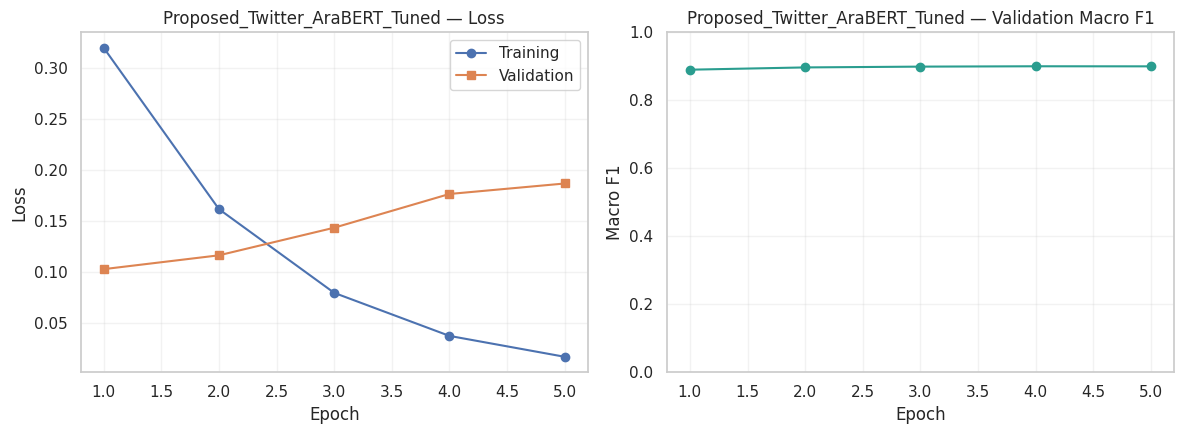

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0.016580,0.176109,5,0.902229,0.902267,0.899036,0.900152,0.902561


Validation: {'eval_loss': 0.1761087328195572, 'eval_accuracy': 0.9022286125089863, 'eval_precision_macro': 0.9022666052151166, 'eval_recall_macro': 0.8990357801702645, 'eval_f1_macro': 0.9001518856545054, 'eval_f1_weighted': 0.9025608095691576}


,precision,recall,f1-score,support
Negative,0.9276,0.8929,0.9099,588.00
Neutral,0.8530,0.8698,0.8613,507.00
Positive,0.8382,0.8721,0.8548,297.00
accuracy,0.8800,0.8800,0.8800,0.88
macro avg,0.8729,0.8782,0.8753,1392.00
weighted avg,0.8813,0.8800,0.8804,1392.00


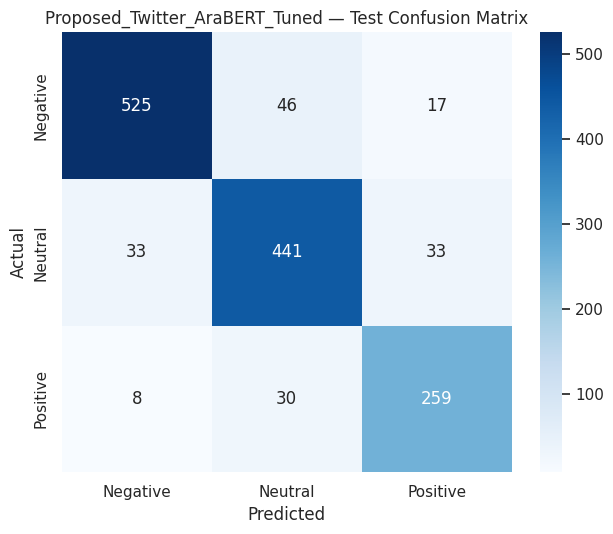

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
proposed_path = train_system(
    "Proposed_Twitter_AraBERT_Tuned",
    PROPOSED_MODEL,
    "clean_tweet",
    BEST_LR,
    "focal",
    5,
    True,
)

In [28]:
import os

print(proposed_path)
print(os.listdir(proposed_path))

GP_Results/models/Proposed_Twitter_AraBERT_Tuned_best
['tokenizer_config.json', 'model.safetensors', 'training_args.bin', 'config.json', 'tokenizer.json']


In [30]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = "GP_Results/models/Proposed_Twitter_AraBERT_Tuned_best"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    use_fast=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

print("✅ Model loaded successfully!")
print("Classes:", model.config.num_labels)
print("id2label:", model.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model loaded successfully!
Classes: 3
id2label: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}


In [31]:
AutoTokenizer.from_pretrained(MODEL_PATH)
AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(64000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [32]:
import shutil

MODEL_PATH = "GP_Results/models/Proposed_Twitter_AraBERT_Tuned_best"

shutil.make_archive(
    "Proposed_Twitter_AraBERT_Tuned_best",
    "zip",
    MODEL_PATH
)

print("✅ ZIP created successfully!")

✅ ZIP created successfully!


In [33]:
import os

print(os.path.abspath("Proposed_Twitter_AraBERT_Tuned_best.zip"))

/content/Proposed_Twitter_AraBERT_Tuned_best.zip


In [34]:
from google.colab import files

files.download("/content/Proposed_Twitter_AraBERT_Tuned_best.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10.1 Final Stage II Model Configuration

This cell records the final checkpoint, data composition, preprocessing,
loss, selected learning rate, split, and seed. It also exports the fixed-test
performance of the seed-42 final model for direct use in the thesis.

In [15]:
seed42_proposed_metrics = next(
    row for row in RESULTS if row["System"] == "Proposed_Twitter_AraBERT_Tuned"
)

final_stage2_configuration = {
    "system_name": "Proposed Stage II",
    "checkpoint": PROPOSED_MODEL,
    "training_sources": "ASTD + ArSAS (ArSAS confidence >= 0.75)",
    "training_rows": int(len(train_df)),
    "validation_rows": int(len(val_df)),
    "combined_test_rows": int(len(test_df)),
    "astd_heldout_test_rows": int(len(astd_test_df)),
    "data_split": "Fixed 80/10/10 split with seed 42, stratified by label and source",
    "input_column": "clean_tweet",
    "preprocessing": (
        "URL/mention placeholders, diacritic/tatweel removal, limited letter "
        "normalization, repetition reduction, whitespace normalization"
    ),
    "loss": "Standard class-weighted focal loss",
    "focal_gamma": float(FOCAL_GAMMA),
    "selected_learning_rate": float(BEST_LR),
    "epochs": int(EPOCHS),
    "max_length": int(MAX_LENGTH),
    "effective_batch_size": int(BATCH_SIZE * GRAD_ACCUM_STEPS),
    "training_seed": int(SEED),
    "saved_checkpoint": proposed_path,
    "combined_test_accuracy": float(seed42_proposed_metrics["accuracy"]),
    "combined_test_macro_f1": float(seed42_proposed_metrics["f1_macro"]),
}

display(pd.DataFrame([final_stage2_configuration]).T.rename(columns={0: "Value"}))
(TABLE_DIR / "final_stage2_configuration.json").write_text(
    json.dumps(final_stage2_configuration, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

,Value
system_name,Proposed Stage II
checkpoint,aubmindlab/bert-base-arabertv02-twitter
training_sources,ASTD + ArSAS (ArSAS confidence >= 0.75)
training_rows,11132
validation_rows,1391
combined_test_rows,1392
astd_heldout_test_rows,322
data_split,"Fixed 80/10/10 split with seed 42, stratified ..."
input_column,clean_tweet
preprocessing,"URL/mention placeholders, diacritic/tatweel re..."


919

## 11. Ensemble Extension — Logit Averaging

The ensemble averages the baseline and proposed **raw test logits** and then
selects the largest averaged logit. It requires no additional model training.
It is reported as an extension, not as the primary proposed model.


,precision,recall,f1-score,support
Negative,0.9338,0.8878,0.9102,588.0000
Neutral,0.8713,0.8679,0.8696,507.0000
Positive,0.8140,0.8990,0.8544,297.0000
accuracy,0.8829,0.8829,0.8829,0.8829
macro avg,0.8730,0.8849,0.8781,1392.0000
weighted avg,0.8855,0.8829,0.8835,1392.0000


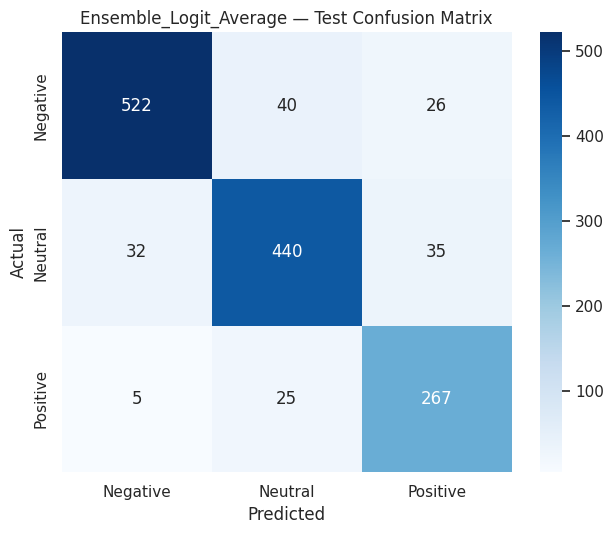

In [16]:
ensemble_logits = (
    LOGITS["Baseline_Standard_AraBERT_Raw"] + LOGITS["Proposed_Twitter_AraBERT_Tuned"]
) / 2.0
y_true = PREDICTIONS["Baseline_Standard_AraBERT_Raw"]["true_id"].to_numpy()
y_pred = np.argmax(ensemble_logits, axis=1)


class _FakeOutput:
    def __init__(self, label_ids, predictions):
        self.label_ids = label_ids
        self.predictions = predictions


record_test(
    "Ensemble_Logit_Average", _FakeOutput(y_true, ensemble_logits), store_logits=True
)

## 12. Seed-42 Diagnostic Comparison

This table is useful for inspecting one complete run and for paired test-set analysis. It is **not** the final evidence for deciding whether the proposed system is better. The final conclusion is produced by the multi-seed section below.


,System,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Classical_TFIDF_LogisticRegression,0.814655,0.805431,0.805466,0.804192,0.814536
1,Baseline_Standard_AraBERT_Raw,0.868534,0.856333,0.873086,0.862474,0.869599
2,Proposed_Twitter_AraBERT_Tuned,0.880029,0.872916,0.878245,0.875331,0.880441
3,Ensemble_Logit_Average,0.882902,0.873041,0.884865,0.878055,0.883494


,Comparison,Accuracy Gain,Macro F1 Gain,Weighted F1 Gain
0,Proposed − Baseline,0.011494,0.012856,0.010842
1,Ensemble − Baseline,0.014368,0.015581,0.013895
2,Ensemble − Proposed,0.002874,0.002724,0.003054


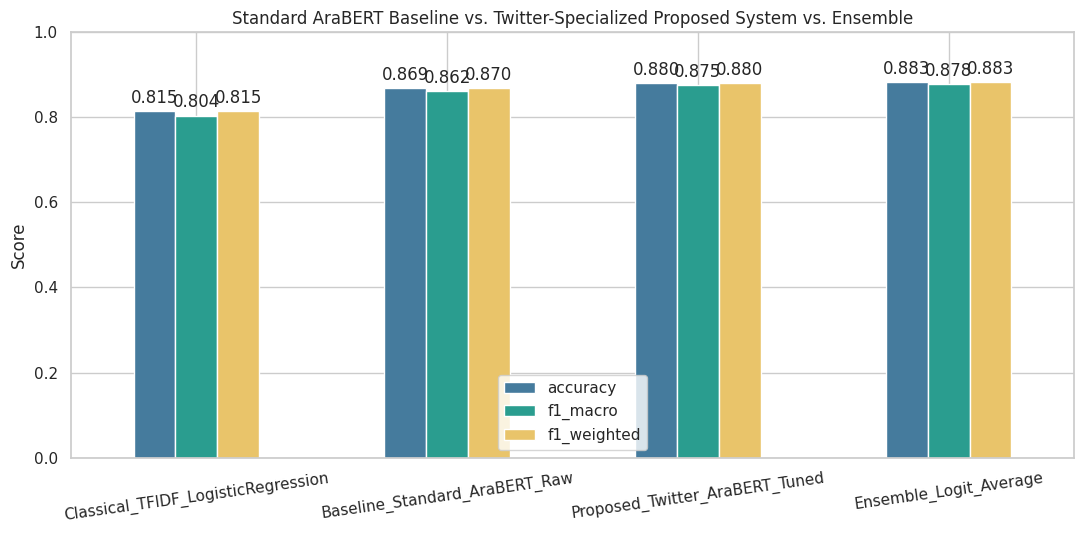

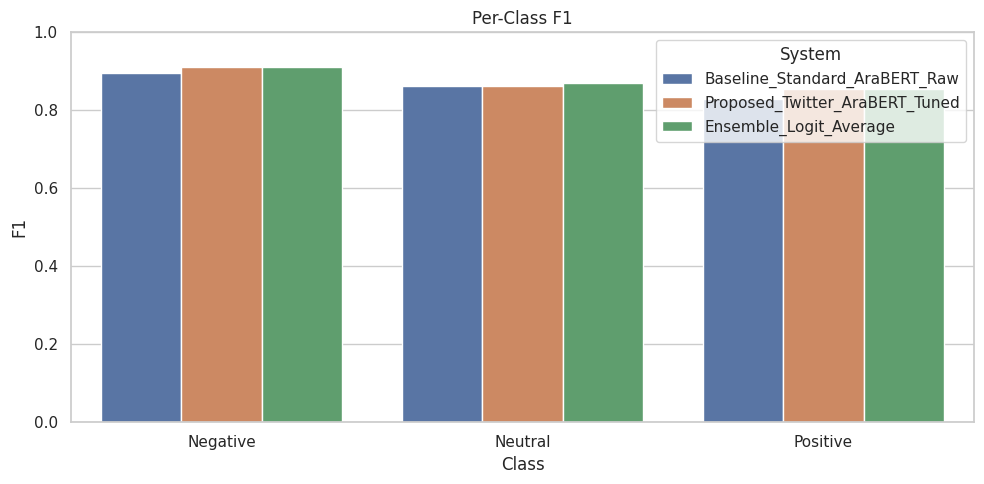

,System,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Weighted F1 (%)
0,TF-IDF + Logistic Regression,81.47,80.54,80.55,80.42,81.45
1,AraBERTv02 Baseline,86.85,85.63,87.31,86.25,86.96
2,Proposed AraBERTv02-Twitter,88.00,87.29,87.82,87.53,88.04
3,Logit-Averaging Ensemble,88.29,87.30,88.49,87.81,88.35


In [17]:
results_df = pd.DataFrame(RESULTS)
results_df.to_csv(TABLE_DIR / "final_system_comparison.csv", index=False)
display(results_df)
b = results_df[results_df.System.eq("Baseline_Standard_AraBERT_Raw")].iloc[0]
p = results_df[results_df.System.eq("Proposed_Twitter_AraBERT_Tuned")].iloc[0]
e = results_df[results_df.System.eq("Ensemble_Logit_Average")].iloc[0]
gains = pd.DataFrame(
    [
        {
            "Comparison": "Proposed − Baseline",
            "Accuracy Gain": p.accuracy - b.accuracy,
            "Macro F1 Gain": p.f1_macro - b.f1_macro,
            "Weighted F1 Gain": p.f1_weighted - b.f1_weighted,
        },
        {
            "Comparison": "Ensemble − Baseline",
            "Accuracy Gain": e.accuracy - b.accuracy,
            "Macro F1 Gain": e.f1_macro - b.f1_macro,
            "Weighted F1 Gain": e.f1_weighted - b.f1_weighted,
        },
        {
            "Comparison": "Ensemble − Proposed",
            "Accuracy Gain": e.accuracy - p.accuracy,
            "Macro F1 Gain": e.f1_macro - p.f1_macro,
            "Weighted F1 Gain": e.f1_weighted - p.f1_weighted,
        },
    ]
)
display(gains)
gains.to_csv(TABLE_DIR / "system_gains.csv", index=False)
ax = results_df.set_index("System")[["accuracy", "f1_macro", "f1_weighted"]].plot(
    kind="bar", figsize=(11, 5.5), color=["#457B9D", "#2A9D8F", "#E9C46A"]
)
ax.set(
    title="Standard AraBERT Baseline vs. Twitter-Specialized Proposed System vs. Ensemble",
    ylabel="Score",
    xlabel="",
    ylim=(0, 1),
)
ax.tick_params(axis="x", rotation=8)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.savefig(FIG_DIR / "final_system_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

pc = []
for name, pdf in PREDICTIONS.items():
    rep = classification_report(
        pdf.true_id,
        pdf.pred_id,
        target_names=label_order,
        output_dict=True,
        zero_division=0,
    )
    for label in label_order:
        pc.append({"System": name, "Class": label, "F1": rep[label]["f1-score"]})
pc = pd.DataFrame(pc)
pc.to_csv(TABLE_DIR / "per_class_f1.csv", index=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=pc, x="Class", y="F1", hue="System")
plt.ylim(0, 1)
plt.title("Per-Class F1")
plt.tight_layout()
plt.savefig(FIG_DIR / "per_class_f1.png", dpi=300, bbox_inches="tight")
plt.show()


table_4_2_names = {
    "Classical_TFIDF_LogisticRegression": "TF-IDF + Logistic Regression",
    "Baseline_Standard_AraBERT_Raw": "AraBERTv02 Baseline",
    "Proposed_Twitter_AraBERT_Tuned": "Proposed AraBERTv02-Twitter",
    "Ensemble_Logit_Average": "Logit-Averaging Ensemble",
}
table_4_2 = results_df[results_df["System"].isin(table_4_2_names)].copy()
table_4_2["System"] = table_4_2["System"].map(table_4_2_names)
for metric in [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
]:
    table_4_2[metric] = table_4_2[metric] * 100
table_4_2 = table_4_2.rename(
    columns={
        "accuracy": "Accuracy (%)",
        "precision_macro": "Macro Precision (%)",
        "recall_macro": "Macro Recall (%)",
        "f1_macro": "Macro F1 (%)",
        "f1_weighted": "Weighted F1 (%)",
    }
)
display(table_4_2.round(2))
table_4_2.to_csv(TABLE_DIR / "table_4_2_system_comparison.csv", index=False)

## 13. Robustness Evaluation Across Three Training Seeds

The learning rate was selected once using the validation set with the fixed tuning seed. The final baseline and proposed configurations are then repeated using seeds **21, 42, and 77** on the same split. Seed 42 was already completed above, so only seeds 21 and 77 are trained here. No seed is selected or discarded based on test performance.



REPLICATION SEED: 21


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.900594,0.316233,0.882099,0.886822,0.872029,0.878064,0.882155
2,0.495135,0.305563,0.884256,0.882844,0.878773,0.880730,0.884169
3,0.336406,0.326373,0.896477,0.893296,0.893010,0.893145,0.896439
4,0.204916,0.369232,0.894321,0.891866,0.890851,0.891353,0.894290
5,0.140863,0.405895,0.894321,0.891785,0.890299,0.891031,0.894276


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

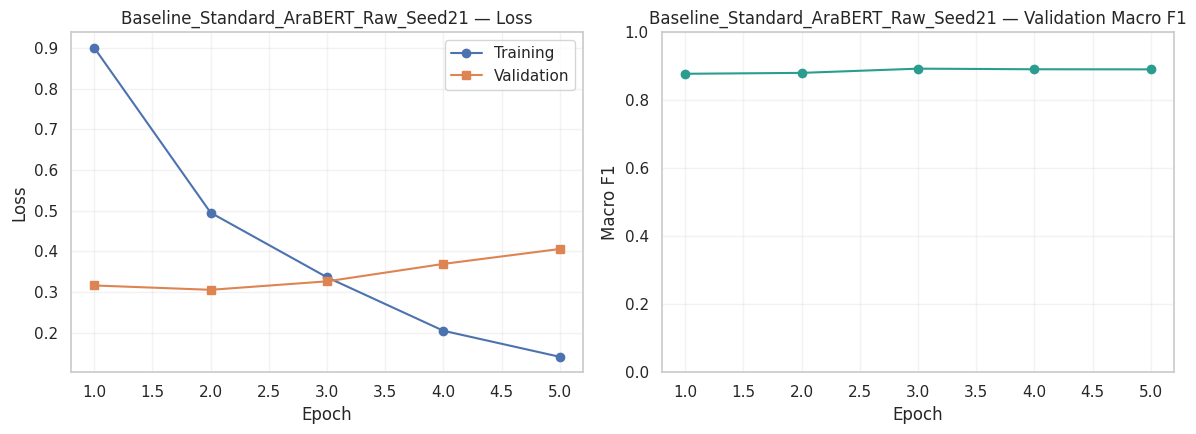

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0.140863,0.326373,5,0.896477,0.893296,0.893010,0.893145,0.896439


Validation: {'eval_loss': 0.32637304067611694, 'eval_accuracy': 0.8964773544212796, 'eval_precision_macro': 0.8932957215745665, 'eval_recall_macro': 0.8930098714569444, 'eval_f1_macro': 0.8931446244611729, 'eval_f1_weighted': 0.8964387068273807}


,precision,recall,f1-score,support
Negative,0.9012,0.8997,0.9004,588.0000
Neutral,0.8864,0.8462,0.8658,507.0000
Positive,0.8193,0.8855,0.8511,297.0000
accuracy,0.8772,0.8772,0.8772,0.8772
macro avg,0.8690,0.8771,0.8725,1392.0000
weighted avg,0.8783,0.8772,0.8773,1392.0000


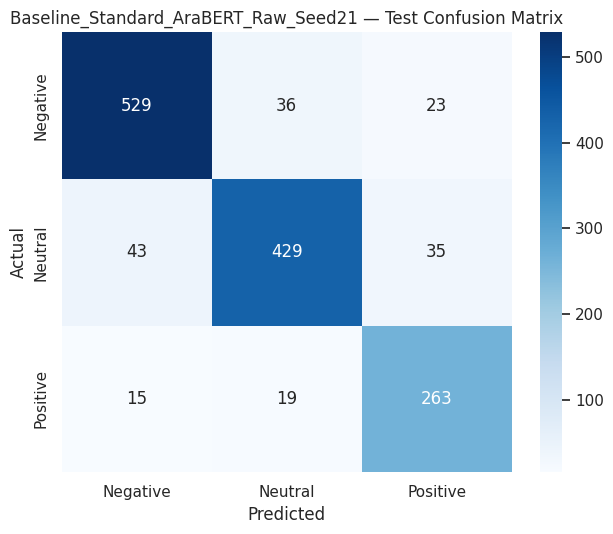

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.302777,0.117325,0.894321,0.885889,0.894332,0.889553,0.894501
2,0.155987,0.144892,0.896477,0.897184,0.888324,0.892391,0.896326
3,0.081584,0.149510,0.901510,0.895237,0.899729,0.897184,0.901482
4,0.033980,0.177875,0.896477,0.893913,0.894307,0.893896,0.896739
5,0.014445,0.193726,0.898634,0.894057,0.895814,0.894920,0.898679


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

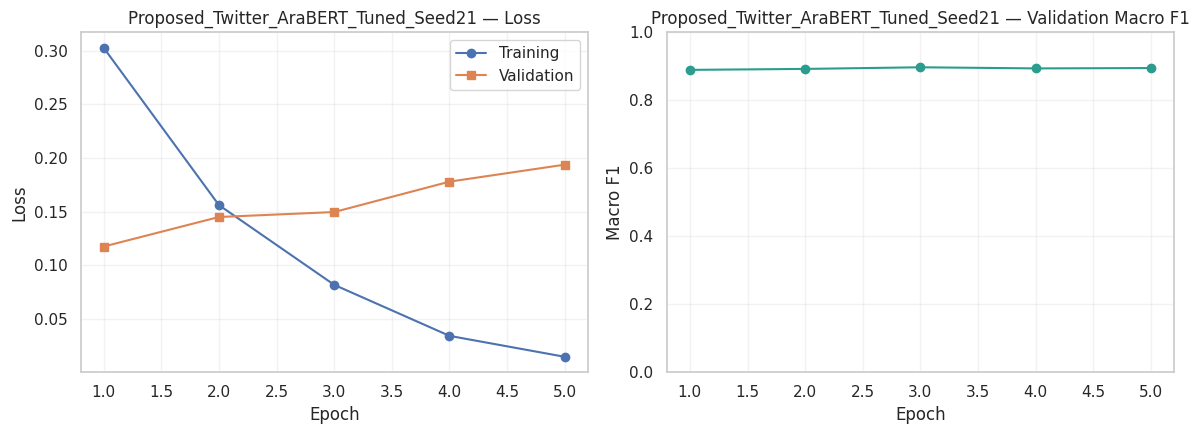

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0.014445,0.149510,5,0.901510,0.895237,0.899729,0.897184,0.901482


Validation: {'eval_loss': 0.14951033890247345, 'eval_accuracy': 0.901509705248023, 'eval_precision_macro': 0.8952374422962658, 'eval_recall_macro': 0.8997291387815677, 'eval_f1_macro': 0.897184370658156, 'eval_f1_weighted': 0.9014817983985098}


,precision,recall,f1-score,support
Negative,0.9116,0.9116,0.9116,588.0000
Neutral,0.8827,0.8462,0.8640,507.0000
Positive,0.8302,0.8889,0.8585,297.0000
accuracy,0.8829,0.8829,0.8829,0.8829
macro avg,0.8748,0.8822,0.8780,1392.0000
weighted avg,0.8837,0.8829,0.8829,1392.0000


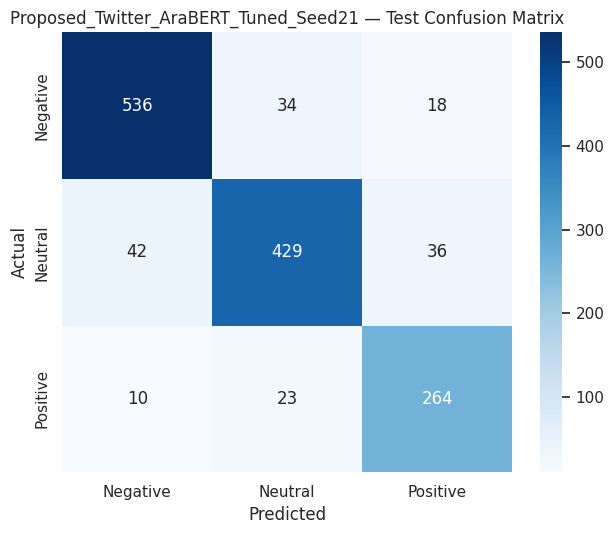

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,precision,recall,f1-score,support
Negative,0.9054,0.9116,0.9085,588.0000
Neutral,0.8931,0.8402,0.8659,507.0000
Positive,0.8204,0.8923,0.8548,297.0000
accuracy,0.8815,0.8815,0.8815,0.8815
macro avg,0.8730,0.8814,0.8764,1392.0000
weighted avg,0.8828,0.8815,0.8815,1392.0000


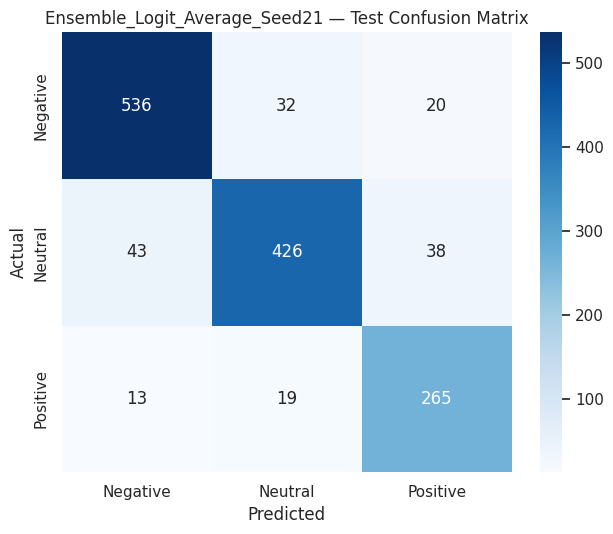


REPLICATION SEED: 77


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.872400,0.298452,0.884975,0.886777,0.879139,0.882529,0.884620
2,0.506046,0.303538,0.884975,0.883449,0.887637,0.884379,0.885283
3,0.326856,0.338793,0.892164,0.896302,0.884729,0.889970,0.891947
4,0.218577,0.347210,0.892164,0.890795,0.890168,0.890392,0.892251
5,0.147235,0.404161,0.893602,0.895285,0.890019,0.892319,0.893729


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

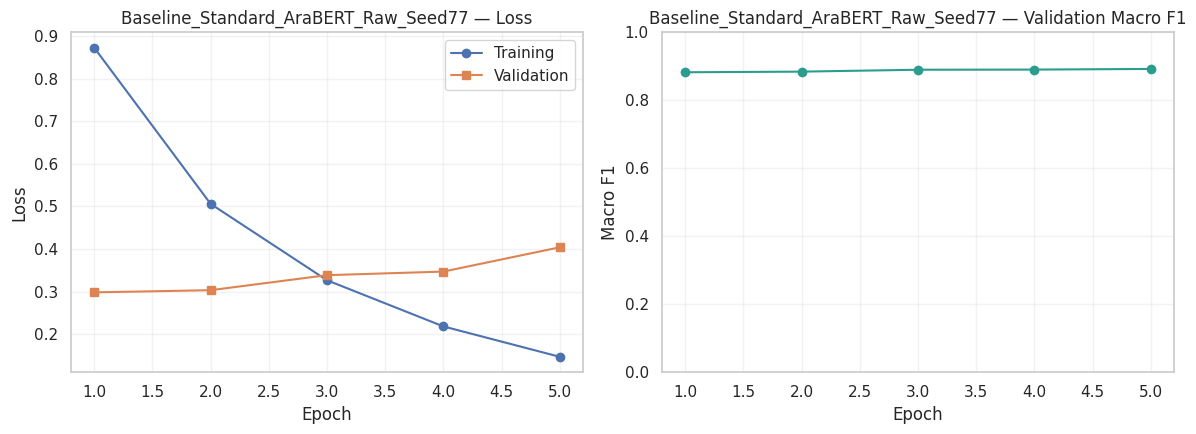

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0.147235,0.404161,5,0.893602,0.895285,0.890019,0.892319,0.893729


Validation: {'eval_loss': 0.4041609764099121, 'eval_accuracy': 0.8936017253774263, 'eval_precision_macro': 0.8952845667147615, 'eval_recall_macro': 0.8900189991605654, 'eval_f1_macro': 0.8923190307842007, 'eval_f1_weighted': 0.8937286618489275}


,precision,recall,f1-score,support
Negative,0.9139,0.8844,0.8989,588.000
Neutral,0.8659,0.8659,0.8659,507.000
Positive,0.8196,0.8721,0.8450,297.000
accuracy,0.8750,0.8750,0.8750,0.875
macro avg,0.8665,0.8741,0.8699,1392.000
weighted avg,0.8763,0.8750,0.8754,1392.000


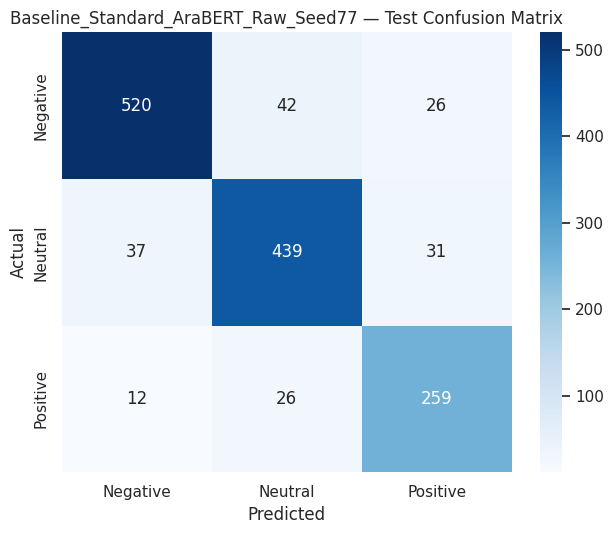

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.306438,0.122328,0.884256,0.884187,0.881897,0.882964,0.884372
2,0.152498,0.123786,0.887132,0.880530,0.890691,0.885016,0.887404
3,0.078537,0.172414,0.892883,0.890443,0.887037,0.888584,0.892594
4,0.033434,0.186552,0.895758,0.889837,0.892536,0.891146,0.895875
5,0.013991,0.218567,0.896477,0.892563,0.891821,0.892114,0.896610


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

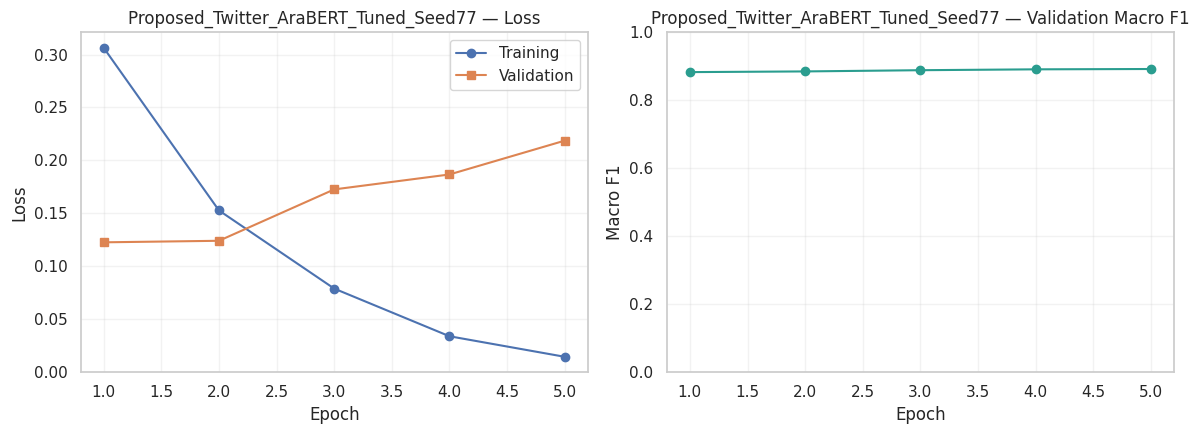

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0.013991,0.218567,5,0.896477,0.892563,0.891821,0.892114,0.896610


Validation: {'eval_loss': 0.21856689453125, 'eval_accuracy': 0.8964773544212796, 'eval_precision_macro': 0.8925627387653076, 'eval_recall_macro': 0.8918207099438886, 'eval_f1_macro': 0.8921142174003975, 'eval_f1_weighted': 0.8966100594773414}


,precision,recall,f1-score,support
Negative,0.9239,0.9082,0.9160,588.0000
Neutral,0.8665,0.8580,0.8622,507.0000
Positive,0.8365,0.8788,0.8571,297.0000
accuracy,0.8836,0.8836,0.8836,0.8836
macro avg,0.8756,0.8816,0.8784,1392.0000
weighted avg,0.8844,0.8836,0.8838,1392.0000


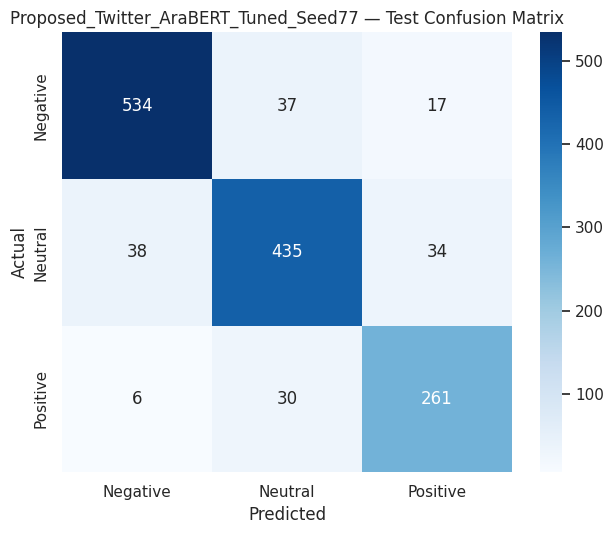

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,precision,recall,f1-score,support
Negative,0.9125,0.9048,0.9086,588.0000
Neutral,0.8802,0.8698,0.8750,507.0000
Positive,0.8474,0.8788,0.8628,297.0000
accuracy,0.8865,0.8865,0.8865,0.8865
macro avg,0.8801,0.8845,0.8821,1392.0000
weighted avg,0.8869,0.8865,0.8866,1392.0000


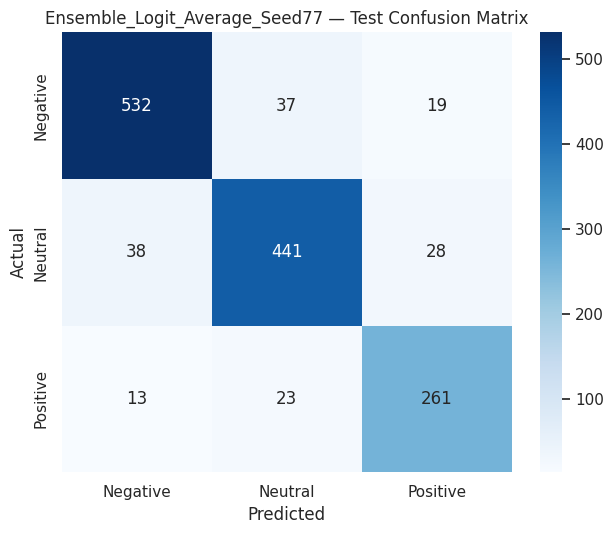

In [18]:
# Train the two missing replications. Seed 42 already exists above.
for run_seed in [s for s in RUN_SEEDS if s != SEED]:
    print(f"\n{'=' * 80}\nREPLICATION SEED: {run_seed}\n{'=' * 80}")

    baseline_name = f"Baseline_Standard_AraBERT_Raw_Seed{run_seed}"
    proposed_name = f"Proposed_Twitter_AraBERT_Tuned_Seed{run_seed}"
    ensemble_name = f"Ensemble_Logit_Average_Seed{run_seed}"

    train_system(
        baseline_name,
        BASELINE_MODEL,
        "raw_tweet",
        2e-5,
        "plain",
        EPOCHS,
        True,
        run_seed=run_seed,
    )
    train_system(
        proposed_name,
        PROPOSED_MODEL,
        "clean_tweet",
        BEST_LR,
        "focal",
        EPOCHS,
        True,
        run_seed=run_seed,
    )

    seed_ensemble_logits = (LOGITS[baseline_name] + LOGITS[proposed_name]) / 2.0
    seed_y_true = PREDICTIONS[baseline_name]["true_id"].to_numpy()
    record_test(
        ensemble_name,
        _FakeOutput(seed_y_true, seed_ensemble_logits),
        store_logits=True,
    )

In [19]:
# Convert run-specific names to three canonical systems.
seed42_map = {
    "Baseline_Standard_AraBERT_Raw": ("Baseline", 42),
    "Proposed_Twitter_AraBERT_Tuned": ("Proposed", 42),
    "Ensemble_Logit_Average": ("Ensemble", 42),
}

rows = []
for row in RESULTS:
    name = row["System"]
    if name in seed42_map:
        system, run_seed = seed42_map[name]
    elif "_Seed" in name:
        run_seed = int(name.rsplit("_Seed", 1)[1])
        if name.startswith("Baseline_"):
            system = "Baseline"
        elif name.startswith("Proposed_"):
            system = "Proposed"
        elif name.startswith("Ensemble_"):
            system = "Ensemble"
        else:
            continue
    else:
        continue
    rows.append(
        {
            "System": system,
            "Seed": run_seed,
            **{k: v for k, v in row.items() if k != "System"},
        }
    )

seed_results_df = (
    pd.DataFrame(rows).sort_values(["System", "Seed"]).reset_index(drop=True)
)
expected = {
    (system, seed)
    for system in ["Baseline", "Proposed", "Ensemble"]
    for seed in RUN_SEEDS
}
observed = set(zip(seed_results_df.System, seed_results_df.Seed))
assert (
    observed == expected
), f"Missing or duplicate runs: expected {expected}, observed {observed}"
seed_results_df.to_csv(TABLE_DIR / "multi_seed_all_runs.csv", index=False)
display(seed_results_df.round(4))

metrics = ["accuracy", "f1_macro", "f1_weighted"]
summary_df = seed_results_df.groupby("System")[metrics].agg(["mean", "std"])
summary_df.columns = [f"{metric}_{stat}" for metric, stat in summary_df.columns]
summary_df = summary_df.reset_index().sort_values("f1_macro_mean", ascending=False)
summary_df.to_csv(TABLE_DIR / "multi_seed_mean_std.csv", index=False)
display(summary_df.round(4))

best_system = summary_df.iloc[0]["System"]
print(f"Best system by mean Macro F1: {best_system}")

,System,Seed,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Baseline,21,0.8772,0.8690,0.8771,0.8725,0.8773
1,Baseline,42,0.8685,0.8563,0.8731,0.8625,0.8696
2,Baseline,77,0.8750,0.8665,0.8741,0.8699,0.8754
3,Ensemble,21,0.8815,0.8730,0.8814,0.8764,0.8815
4,Ensemble,42,0.8829,0.8730,0.8849,0.8781,0.8835
5,Ensemble,77,0.8865,0.8801,0.8845,0.8821,0.8866
6,Proposed,21,0.8829,0.8748,0.8822,0.8780,0.8829
7,Proposed,42,0.8800,0.8729,0.8782,0.8753,0.8804
8,Proposed,77,0.8836,0.8756,0.8816,0.8784,0.8838


,System,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
1,Ensemble,0.8836,0.0026,0.8789,0.0030,0.8839,0.0026
2,Proposed,0.8822,0.0019,0.8773,0.0017,0.8824,0.0018
0,Baseline,0.8736,0.0045,0.8683,0.0052,0.8741,0.0040


Best system by mean Macro F1: Ensemble


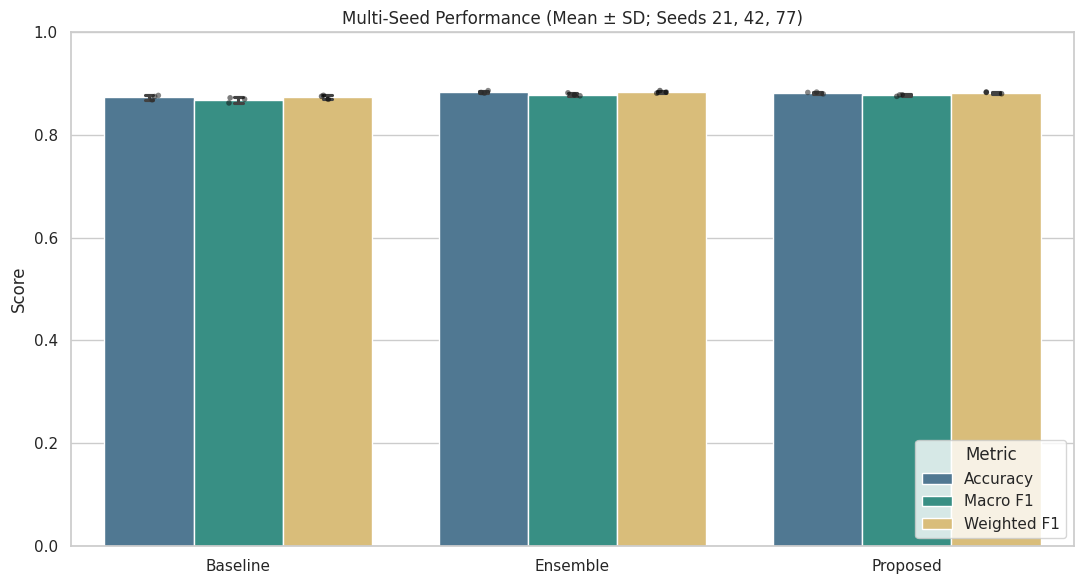

,Seed,Proposed_minus_Baseline_Accuracy,Proposed_minus_Baseline_Macro_F1,Ensemble_minus_Baseline_Accuracy,Ensemble_minus_Baseline_Macro_F1
0,21,0.0057,0.0056,0.0043,0.0039
1,42,0.0115,0.0129,0.0144,0.0156
2,77,0.0086,0.0085,0.0115,0.0122


In [20]:
# Publication-quality mean ± standard-deviation comparison.
plot_long = seed_results_df.melt(
    id_vars=["System", "Seed"],
    value_vars=["accuracy", "f1_macro", "f1_weighted"],
    var_name="Metric",
    value_name="Score",
)
metric_names = {
    "accuracy": "Accuracy",
    "f1_macro": "Macro F1",
    "f1_weighted": "Weighted F1",
}
plot_long["Metric"] = plot_long["Metric"].map(metric_names)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=plot_long,
    x="System",
    y="Score",
    hue="Metric",
    errorbar="sd",
    capsize=0.08,
    palette=["#457B9D", "#2A9D8F", "#E9C46A"],
    ax=ax,
)
sns.stripplot(
    data=plot_long,
    x="System",
    y="Score",
    hue="Metric",
    dodge=True,
    color="black",
    alpha=0.55,
    size=4,
    legend=False,
    ax=ax,
)
ax.set(
    title="Multi-Seed Performance (Mean ± SD; Seeds 21, 42, 77)",
    ylabel="Score",
    xlabel="",
    ylim=(0, 1),
)
ax.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "multi_seed_mean_std.png", dpi=300, bbox_inches="tight")
plt.show()

# Paired seed-level differences; positive values favor Proposed/Ensemble.
pivot = seed_results_df.pivot(
    index="Seed", columns="System", values=["accuracy", "f1_macro"]
)
seed_differences = pd.DataFrame(
    {
        "Seed": RUN_SEEDS,
        "Proposed_minus_Baseline_Accuracy": (
            pivot["accuracy"]["Proposed"] - pivot["accuracy"]["Baseline"]
        )
        .reindex(RUN_SEEDS)
        .values,
        "Proposed_minus_Baseline_Macro_F1": (
            pivot["f1_macro"]["Proposed"] - pivot["f1_macro"]["Baseline"]
        )
        .reindex(RUN_SEEDS)
        .values,
        "Ensemble_minus_Baseline_Accuracy": (
            pivot["accuracy"]["Ensemble"] - pivot["accuracy"]["Baseline"]
        )
        .reindex(RUN_SEEDS)
        .values,
        "Ensemble_minus_Baseline_Macro_F1": (
            pivot["f1_macro"]["Ensemble"] - pivot["f1_macro"]["Baseline"]
        )
        .reindex(RUN_SEEDS)
        .values,
    }
)
seed_differences.to_csv(TABLE_DIR / "paired_seed_differences.csv", index=False)
display(seed_differences.round(4))

## 13.1 Final Proposed Model on Held-Out Egyptian Tweets

Each final proposed checkpoint is evaluated on the same unseen ASTD subset of
the fixed Stage II test partition. The table reports all training seeds and
their mean ± standard deviation. The confusion matrix is shown for seed 42 as
a transparent diagnostic; it is not computed on training data.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

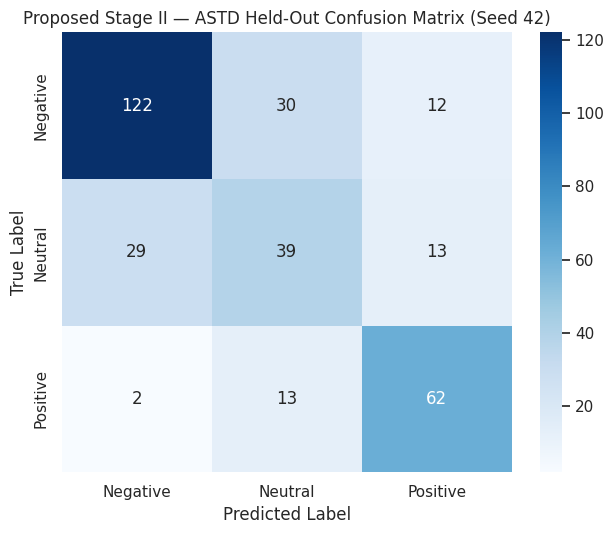

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,Seed,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,21,0.7112,0.6730,0.6791,0.6702,0.7004
1,42,0.6925,0.6619,0.6769,0.6681,0.6932
2,77,0.7081,0.6726,0.6852,0.6773,0.7047


,Metric,Mean ± SD (%)
0,accuracy,70.39 ± 1.00
1,precision_macro,66.92 ± 0.63
2,recall_macro,68.04 ± 0.43
3,f1_macro,67.19 ± 0.48
4,f1_weighted,69.94 ± 0.58


In [21]:
def evaluate_checkpoint_on_frame(
    checkpoint_path, frame, text_column, evaluation_name, plot_confusion=False
):
    tokenizer = AutoTokenizer.from_pretrained(str(checkpoint_path), use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(checkpoint_path))
    dataset = TweetDataset(frame[text_column], frame["label"], tokenizer)

    args = TrainingArguments(
        output_dir=str(MODEL_DIR / f"eval_{evaluation_name}"),
        per_device_eval_batch_size=32,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )
    trainer = Trainer(
        model=model,
        args=args,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )
    output = trainer.predict(dataset)
    y_true = output.label_ids
    y_pred = np.argmax(output.predictions, axis=1)
    metrics = metrics_dict(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=label_order,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(
        TABLE_DIR / f"{evaluation_name}_classification_report.csv"
    )

    predictions = frame[["raw_tweet", "source", "comparison_key"]].copy()
    predictions["true_id"] = y_true
    predictions["pred_id"] = y_pred
    predictions["true_label"] = predictions["true_id"].map(id2label)
    predictions["pred_label"] = predictions["pred_id"].map(id2label)
    predictions["correct"] = predictions["true_id"].eq(predictions["pred_id"])
    predictions.to_csv(TABLE_DIR / f"{evaluation_name}_predictions.csv", index=False)

    if plot_confusion:
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=label_order,
            yticklabels=label_order,
            ax=ax,
        )
        ax.set_title("Proposed Stage II — ASTD Held-Out Confusion Matrix (Seed 42)")
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")
        plt.tight_layout()
        plt.savefig(
            FIG_DIR / "proposed_stage2_astd_heldout_confusion_seed42.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

    del trainer, model, dataset
    gc.collect()
    torch.cuda.empty_cache()
    return metrics


astd_seed_rows = []
for run_seed in RUN_SEEDS:
    if run_seed == SEED:
        system_name = "Proposed_Twitter_AraBERT_Tuned"
    else:
        system_name = f"Proposed_Twitter_AraBERT_Tuned_Seed{run_seed}"

    checkpoint_path = MODEL_DIR / f"{system_name}_best"
    assert checkpoint_path.exists(), f"Missing checkpoint: {checkpoint_path}"

    run_metrics = evaluate_checkpoint_on_frame(
        checkpoint_path,
        astd_test_df,
        "clean_tweet",
        f"Proposed_ASTDHeldout_Seed{run_seed}",
        plot_confusion=(run_seed == SEED),
    )
    astd_seed_rows.append({"Seed": run_seed, **run_metrics})

astd_seed_results_df = pd.DataFrame(astd_seed_rows).sort_values("Seed")
display(astd_seed_results_df.round(4))
astd_seed_results_df.to_csv(
    TABLE_DIR / "proposed_astd_heldout_all_seeds.csv", index=False
)

astd_summary = (
    astd_seed_results_df[
        ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]
    ]
    .agg(["mean", "std"])
    .T
)
astd_summary.index.name = "Metric"
astd_summary = astd_summary.reset_index()
astd_summary["Mean ± SD (%)"] = astd_summary.apply(
    lambda row: f'{row["mean"] * 100:.2f} ± {row["std"] * 100:.2f}', axis=1
)
display(astd_summary[["Metric", "Mean ± SD (%)"]])
astd_summary.to_csv(TABLE_DIR / "proposed_astd_heldout_mean_std.csv", index=False)

### Reporting Note

Report this result as:

> The final Stage II checkpoints were additionally evaluated on the ASTD rows
> within the fixed held-out Stage II test partition. These Egyptian tweets were
> excluded from training, validation, and hyperparameter selection.

Do **not** describe it as evaluation on the full ASTD dataset or automatically
equate it with the ASTD-only split from another experimental track.

For the ablation limitation, use:

> A fully matched Stage II ablation was not conducted because of computational
> and time constraints. The controlled experiments elsewhere in the project
> provide only indirect evidence about individual design choices; a complete
> one-factor-at-a-time Stage II ablation is left for future work.

## 14. Seed-42 Paired Statistical Significance Analysis

Exact McNemar tests compare paired correctness decisions, while stratified bootstrap intervals quantify uncertainty in Macro F1 differences.


## 15. Qualitative Error Analysis and Artifact Export

Misclassified examples are exported for each system to support the error-analysis discussion in Chapters 4 and 5. The complete results package is downloaded as a ZIP archive.


In [22]:
def mcnemar_pair(name_a, name_b):
    a = PREDICTIONS[name_a]
    b = PREDICTIONS[name_b]
    assert np.array_equal(a.true_id.to_numpy(), b.true_id.to_numpy())
    n01 = int((~a.correct & b.correct).sum())
    n10 = int((a.correct & ~b.correct).sum())
    pv = binomtest(min(n01, n10), n=n01 + n10, p=0.5).pvalue if n01 + n10 else 1.0
    return {
        "A": name_a,
        "B": name_b,
        "A_wrong_B_correct": n01,
        "A_correct_B_wrong": n10,
        "McNemar_p": pv,
    }


def boot(y, a, z, reps=2000):
    rng = np.random.default_rng(SEED)
    out = []
    n = len(y)
    for _ in range(reps):
        ix = rng.integers(0, n, n)
        out.append(
            precision_recall_fscore_support(
                y[ix], z[ix], average="macro", zero_division=0
            )[2]
            - precision_recall_fscore_support(
                y[ix], a[ix], average="macro", zero_division=0
            )[2]
        )
    return np.percentile(out, [2.5, 50, 97.5])


pairs = [
    ("Baseline_Standard_AraBERT_Raw", "Proposed_Twitter_AraBERT_Tuned"),
    ("Baseline_Standard_AraBERT_Raw", "Ensemble_Logit_Average"),
    ("Proposed_Twitter_AraBERT_Tuned", "Ensemble_Logit_Average"),
]

sig_rows = []
for name_a, name_b in pairs:
    row = mcnemar_pair(name_a, name_b)
    sig_rows.append(row)
    y = PREDICTIONS[name_a].true_id.to_numpy()
    ci = boot(
        y,
        PREDICTIONS[name_a].pred_id.to_numpy(),
        PREDICTIONS[name_b].pred_id.to_numpy(),
    )
    row["Macro_F1_gain_CI_low"] = ci[0]
    row["Macro_F1_gain_CI_median"] = ci[1]
    row["Macro_F1_gain_CI_high"] = ci[2]
    print(name_a, "vs", name_b, "->", row)

sig_df = pd.DataFrame(sig_rows)
sig_df.to_csv(TABLE_DIR / "significance_tests.csv", index=False)
display(sig_df)

Baseline_Standard_AraBERT_Raw vs Proposed_Twitter_AraBERT_Tuned -> {'A': 'Baseline_Standard_AraBERT_Raw', 'B': 'Proposed_Twitter_AraBERT_Tuned', 'A_wrong_B_correct': 62, 'A_correct_B_wrong': 46, 'McNemar_p': np.float64(0.14857634761056238), 'Macro_F1_gain_CI_low': np.float64(-0.002498503670466909), 'Macro_F1_gain_CI_median': np.float64(0.01316341719318409), 'Macro_F1_gain_CI_high': np.float64(0.027648394654920673)}
Baseline_Standard_AraBERT_Raw vs Ensemble_Logit_Average -> {'A': 'Baseline_Standard_AraBERT_Raw', 'B': 'Ensemble_Logit_Average', 'A_wrong_B_correct': 33, 'A_correct_B_wrong': 13, 'McNemar_p': np.float64(0.004533861582189047), 'Macro_F1_gain_CI_low': np.float64(0.00633975898317263), 'Macro_F1_gain_CI_median': np.float64(0.015622428255426035), 'Macro_F1_gain_CI_high': np.float64(0.025584973318064728)}
Proposed_Twitter_AraBERT_Tuned vs Ensemble_Logit_Average -> {'A': 'Proposed_Twitter_AraBERT_Tuned', 'B': 'Ensemble_Logit_Average', 'A_wrong_B_correct': 34, 'A_correct_B_wrong': 3

,A,B,A_wrong_B_correct,A_correct_B_wrong,McNemar_p,Macro_F1_gain_CI_low,Macro_F1_gain_CI_median,Macro_F1_gain_CI_high
0,Baseline_Standard_AraBERT_Raw,Proposed_Twitter_AraBERT_Tuned,62,46,0.148576,-0.002499,0.013163,0.027648
1,Baseline_Standard_AraBERT_Raw,Ensemble_Logit_Average,33,13,0.004534,0.006340,0.015622,0.025585
2,Proposed_Twitter_AraBERT_Tuned,Ensemble_Logit_Average,34,30,0.707981,-0.009162,0.002705,0.014891


In [23]:
for name, pdf in PREDICTIONS.items():
    errors = pdf.query("not correct")
    errors.to_csv(TABLE_DIR / f"{name}_errors.csv", index=False)
    print(name, "errors:", len(errors))
    display(
        errors[["text", "true_label", "pred_label"]].sample(
            min(12, len(errors)), random_state=SEED
        )
    )
import shutil

archive = shutil.make_archive("Standard_vs_Twitter_AraBERT_Results", "zip", OUTPUT_ROOT)
from google.colab import files

files.download(archive)

Baseline_Standard_AraBERT_Raw errors: 183


,text,true_label,pred_label
178,ياباشمهندس لو الرقم اللي هم بينشروه عشان يبعتو...,Neutral,Negative
314,الإسلام شيء غير هذا المعنى الذي أراد خصومه أن ...,Positive,Neutral
1221,مبارك يوم 24 يناير كان أقوى بكثير من مرسي الان...,Neutral,Negative
851,ولي العهد السعودي يعتقل ١١ أميراً علي رأسهم مت...,Neutral,Negative
1144,انا عايزة اعضاء الزمالك يبهروني وينتخبوا مرتضى...,Negative,Positive
160,مقابلة مع : لماذا تركز معظم المحاكمات في بلدان...,Negative,Neutral
206,"صاحب ""بطيخة #محمد_صلاح"" يحكي قصة النحت على الف...",Neutral,Positive
507,جابر ، هل انت مقتنع بخطاب اميرك ؟ يتحدث عن حصا...,Negative,Positive
898,أحمد سليمان مع شوبير معليين الرتم علي مرتضي من...,Positive,Neutral
742,أهم الأحداث العربية التي أدركتها في حياتي: -ال...,Negative,Neutral


Proposed_Twitter_AraBERT_Tuned errors: 167


,text,true_label,pred_label
819,فيديو ترحيب حار من الأقباط لـ #توفيق_عكاشة و #...,Negative,Positive
874,حتى و هو معهم طلعهم كريستيانو من تصفيات كأس ال...,Positive,Negative
645,#سوايسة_ضد_الإنقلاب | #منتدي_الشباب_فشنك تعرف ...,Negative,Neutral
465,من لا يعرف أمه إلا يوما في السنة فهو عاق لها، ...,Negative,Neutral
793,للعلم ده مهرجان درجة أولى ما لو بالفلوس ما كان...,Neutral,Negative
281,لي محمد صلاح شو افريقي؟,Neutral,Positive
853,كانوا أقزاما مع ناصر والسادات ومبارك وطنطاوى و...,Neutral,Negative
687,كوبي بست اللي قالهولي انصار حمدين صباحي والله,Negative,Positive
852,محمد صلاح نافع أجمل الأصوات سورة الكهف كاملة h...,Neutral,Positive
888,شباب حزب الوسط حاجة تفرح بجد الله يخرب بيتك يا...,Neutral,Positive


Ensemble_Logit_Average errors: 163


...

,text,true_label,pred_label
1348,#السيسي للشباب المشاركون بجلسة الأمم المتحدة: ...,Neutral,Positive
913,الفرق بين مليونية اليوم ومليونية غيرها ، إن ال...,Neutral,Negative
1161,مفيش بنا اي اختلاف بالرائي بالعكس أستاذه مريم ...,Positive,Negative
478,معلش بقى لا #النور ولا #الاخوان ولا الكلام الف...,Neutral,Positive
793,للعلم ده مهرجان درجة أولى ما لو بالفلوس ما كان...,Neutral,Negative
286,بقيت كلما أتفرج على حلقة لباسم أفتكر صديقنا ال...,Neutral,Negative
853,كانوا أقزاما مع ناصر والسادات ومبارك وطنطاوى و...,Neutral,Negative
455,#سؤال_برئ كل الناس يوم الجمعه تنزل صور وتكتب #...,Neutral,Negative
851,ولي العهد السعودي يعتقل ١١ أميراً علي رأسهم مت...,Neutral,Negative
1269,1 وصلتنى رسالة من مشجع كروى الى طاهر ابو زيد: ...,Neutral,Negative


Ensemble_Logit_Average_Seed77 errors: 158


,text,true_label,pred_label
1147,كيني دالجليش أسطورة #ليفربول يشيد بنجم الفريق ...,Neutral,Positive
352,"النائب خالد عبدالعزيز: منتدى ""شباب العالم"" نجح...",Neutral,Positive
1181,"""في الخارج لو كان لديك حق ستأخذه، أما هنا فحق ...",Negative,Neutral
1369,أرفض تماما أي دعاوى تطلق لفرض سلطة ووصاية مؤسس...,Neutral,Negative
761,#وليد_الاحمد : الحرب تدق ابوابنا ! جريدة الراي...,Negative,Neutral
230,بدايه انقلاب على خليفه حفتر غالبا,Neutral,Negative
808,اطاح الاستفتاء بمبدأ تكافؤ الفرص حينما لم يسمح...,Neutral,Negative
837,يوم الوفاء للرئيس؟! مين وفاء دي؟ مش واخد بالي,Negative,Positive
801,فيديو.. أهداف فوز #ليفربول على ساوثامبتون وثنا...,Positive,Neutral
1263,وزير دفاع إسرائيل يفجر قنبلة مدوية عن «تيران و...,Negative,Neutral


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FINAL MULTI-SEED RESULTS
Stored result records: 10
Skipped unrecognized result: Classical_TFIDF_LogisticRegression

Detected systems: ['Baseline', 'Ensemble', 'Proposed']
Detected seeds: [np.int64(21), np.int64(42), np.int64(77)]
Valid final runs: 9

Verification passed: all 9 runs are available.

TABLE 1 — ALL INDIVIDUAL RUNS
  System  Seed  Accuracy  Precision Macro  Recall Macro  Macro F1  Weighted F1
Baseline    21     87.72            86.90         87.71     87.25        87.73
Baseline    42     86.85            85.63         87.31     86.25        86.96
Baseline    77     87.50            86.65         87.41     86.99        87.54
Ensemble    21     88.15            87.30         88.14     87.64        88.15
Ensemble    42     88.29            87.30         88.49     87.81        88.35
Ensemble    77     88.65            88.01         88.45     88.21        88.66
Proposed    21     88.29            87.48         88.22     87.80        88.29
Proposed    42     88.00            87.

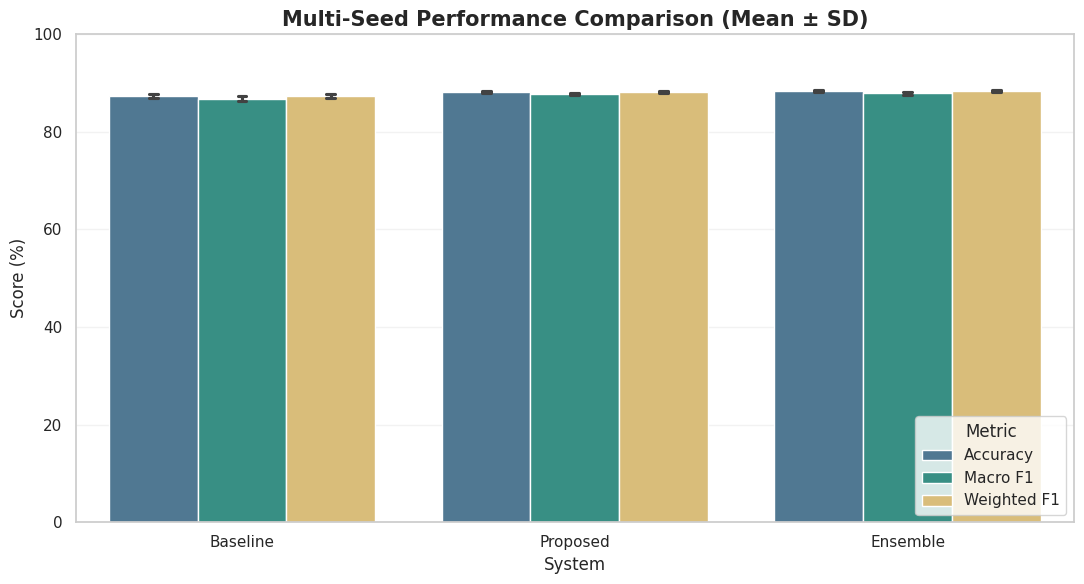


FILES SAVED SUCCESSFULLY
Final_MultiSeed_Results/01_all_individual_runs_percent.csv
Final_MultiSeed_Results/02_mean_standard_deviation_percent.csv
Final_MultiSeed_Results/03_thesis_ready_results.csv
Final_MultiSeed_Results/04_average_performance_gains.csv
Final_MultiSeed_Results/final_multi_seed_comparison.png


In [24]:
# ============================================================
# FINAL MULTI-SEED RESULTS — NO RETRAINING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")

RESULTS_DIR = Path("Final_MultiSeed_Results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("FINAL MULTI-SEED RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Verify that all training results still exist
# ------------------------------------------------------------

if "RESULTS" not in globals():
    raise RuntimeError(
        "RESULTS is not available. The Colab runtime may have restarted."
    )

print("Stored result records:", len(RESULTS))

if len(RESULTS) < 9:
    print(
        "WARNING: Expected 9 results " "(3 systems × 3 seeds), but found:", len(RESULTS)
    )

# ------------------------------------------------------------
# 2. Convert original experiment names
# ------------------------------------------------------------

seed_42_names = {
    "Baseline_Standard_AraBERT_Raw": ("Baseline", 42),
    "Proposed_Twitter_AraBERT_Tuned": ("Proposed", 42),
    "Ensemble_Logit_Average": ("Ensemble", 42),
}

final_rows = []

for result in RESULTS:

    original_name = str(result.get("System", ""))

    # Original seed-42 run
    if original_name in seed_42_names:
        system_name, run_seed = seed_42_names[original_name]

    # Replication runs: Seed21 and Seed77
    elif "_Seed" in original_name:

        try:
            run_seed = int(original_name.rsplit("_Seed", 1)[1])
        except ValueError:
            print("Skipped unrecognized result:", original_name)
            continue

        if original_name.startswith("Baseline"):
            system_name = "Baseline"

        elif original_name.startswith("Proposed"):
            system_name = "Proposed"

        elif original_name.startswith("Ensemble"):
            system_name = "Ensemble"

        else:
            print("Skipped unrecognized system:", original_name)
            continue

    else:
        print("Skipped unrecognized result:", original_name)
        continue

    final_rows.append(
        {
            "System": system_name,
            "Seed": run_seed,
            "Accuracy": float(result["accuracy"]),
            "Precision Macro": float(result["precision_macro"]),
            "Recall Macro": float(result["recall_macro"]),
            "Macro F1": float(result["f1_macro"]),
            "Weighted F1": float(result["f1_weighted"]),
        }
    )

all_results = pd.DataFrame(final_rows)

if all_results.empty:
    raise RuntimeError("No valid result records were found.")

# Remove accidental duplicate records
all_results = (
    all_results.drop_duplicates(subset=["System", "Seed"], keep="last")
    .sort_values(["System", "Seed"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Verify expected systems and seeds
# ------------------------------------------------------------

expected_systems = {"Baseline", "Proposed", "Ensemble"}
expected_seeds = {21, 42, 77}

print("\nDetected systems:", sorted(all_results["System"].unique()))
print("Detected seeds:", sorted(all_results["Seed"].unique()))
print("Valid final runs:", len(all_results))

missing_runs = []

for system in expected_systems:
    for seed in expected_seeds:

        exists = (
            (all_results["System"] == system) & (all_results["Seed"] == seed)
        ).any()

        if not exists:
            missing_runs.append((system, seed))

if missing_runs:
    print("\nWARNING — Missing runs:", missing_runs)
else:
    print("\nVerification passed: all 9 runs are available.")

# ------------------------------------------------------------
# 4. Display every individual result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TABLE 1 — ALL INDIVIDUAL RUNS")
print("=" * 70)

all_results_percent = all_results.copy()

metric_columns = [
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "Macro F1",
    "Weighted F1",
]

all_results_percent[metric_columns] = all_results_percent[metric_columns] * 100

print(all_results_percent.round(2).to_string(index=False))

# ------------------------------------------------------------
# 5. Calculate Mean ± Standard Deviation
# ------------------------------------------------------------

summary = all_results.groupby("System")[metric_columns].agg(["mean", "std"])

summary.columns = [f"{metric} {stat.capitalize()}" for metric, stat in summary.columns]

summary = (
    summary.reset_index()
    .sort_values("Macro F1 Mean", ascending=False)
    .reset_index(drop=True)
)

summary_percent = summary.copy()

numeric_summary_columns = summary_percent.columns.drop("System")
summary_percent[numeric_summary_columns] *= 100

print("\n" + "=" * 70)
print("TABLE 2 — FINAL MEAN ± STANDARD DEVIATION (%)")
print("=" * 70)

print(summary_percent.round(2).to_string(index=False))

# ------------------------------------------------------------
# 6. Thesis-ready formatted table
# ------------------------------------------------------------

formatted_rows = []

for _, row in summary.iterrows():

    formatted_rows.append(
        {
            "System": row["System"],
            "Accuracy (%)": (
                f'{row["Accuracy Mean"] * 100:.2f} '
                f'± {row["Accuracy Std"] * 100:.2f}'
            ),
            "Macro F1 (%)": (
                f'{row["Macro F1 Mean"] * 100:.2f} '
                f'± {row["Macro F1 Std"] * 100:.2f}'
            ),
            "Weighted F1 (%)": (
                f'{row["Weighted F1 Mean"] * 100:.2f} '
                f'± {row["Weighted F1 Std"] * 100:.2f}'
            ),
        }
    )

thesis_table = pd.DataFrame(formatted_rows)

print("\n" + "=" * 70)
print("TABLE 3 — THESIS-READY RESULTS")
print("=" * 70)

print(thesis_table.to_string(index=False))

# ------------------------------------------------------------
# 7. Calculate Proposed and Ensemble improvements
# ------------------------------------------------------------

mean_results = all_results.groupby("System")[metric_columns].mean()

gain_rows = []

comparisons = [
    ("Proposed", "Baseline"),
    ("Ensemble", "Baseline"),
    ("Ensemble", "Proposed"),
]

for better_system, reference_system in comparisons:

    if better_system in mean_results.index and reference_system in mean_results.index:

        gain_rows.append(
            {
                "Comparison": f"{better_system} − {reference_system}",
                "Accuracy Gain (pp)": (
                    mean_results.loc[better_system, "Accuracy"]
                    - mean_results.loc[reference_system, "Accuracy"]
                )
                * 100,
                "Macro F1 Gain (pp)": (
                    mean_results.loc[better_system, "Macro F1"]
                    - mean_results.loc[reference_system, "Macro F1"]
                )
                * 100,
                "Weighted F1 Gain (pp)": (
                    mean_results.loc[better_system, "Weighted F1"]
                    - mean_results.loc[reference_system, "Weighted F1"]
                )
                * 100,
            }
        )

gains_table = pd.DataFrame(gain_rows)

print("\n" + "=" * 70)
print("TABLE 4 — AVERAGE PERFORMANCE GAINS")
print("=" * 70)

print(gains_table.round(3).to_string(index=False))

# ------------------------------------------------------------
# 8. Determine the final winning system
# ------------------------------------------------------------

best_macro_system = summary.iloc[0]["System"]
best_macro_value = summary.iloc[0]["Macro F1 Mean"]

best_accuracy_row = summary.loc[summary["Accuracy Mean"].idxmax()]

best_accuracy_system = best_accuracy_row["System"]
best_accuracy_value = best_accuracy_row["Accuracy Mean"]

print("\n" + "=" * 70)
print("FINAL CONCLUSION")
print("=" * 70)

print(
    f"Best system by mean Macro F1: "
    f"{best_macro_system} ({best_macro_value * 100:.2f}%)"
)

print(
    f"Best system by mean Accuracy: "
    f"{best_accuracy_system} ({best_accuracy_value * 100:.2f}%)"
)

if "Proposed" in mean_results.index and "Baseline" in mean_results.index:

    proposed_macro = mean_results.loc["Proposed", "Macro F1"]
    baseline_macro = mean_results.loc["Baseline", "Macro F1"]

    difference = (proposed_macro - baseline_macro) * 100

    if difference > 0:
        print(
            f"Proposed outperformed Baseline in mean Macro F1 "
            f"by {difference:.3f} percentage points."
        )
    elif difference < 0:
        print(
            f"Proposed was lower than Baseline in mean Macro F1 "
            f"by {abs(difference):.3f} percentage points."
        )
    else:
        print("Proposed and Baseline obtained identical mean Macro F1.")

# ------------------------------------------------------------
# 9. Professional comparison figure
# ------------------------------------------------------------

plot_data = all_results.melt(
    id_vars=["System", "Seed"],
    value_vars=["Accuracy", "Macro F1", "Weighted F1"],
    var_name="Metric",
    value_name="Score",
)

plot_data["Score (%)"] = plot_data["Score"] * 100

system_order = ["Baseline", "Proposed", "Ensemble"]
system_order = [
    system for system in system_order if system in plot_data["System"].unique()
]

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=plot_data,
    x="System",
    y="Score (%)",
    hue="Metric",
    order=system_order,
    errorbar="sd",
    capsize=0.08,
    palette={
        "Accuracy": "#457B9D",
        "Macro F1": "#2A9D8F",
        "Weighted F1": "#E9C46A",
    },
    ax=ax,
)

ax.set_title(
    "Multi-Seed Performance Comparison (Mean ± SD)",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("System")
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 100)
ax.legend(title="Metric", loc="lower right")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

figure_path = RESULTS_DIR / "final_multi_seed_comparison.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# 10. Save all final tables
# ------------------------------------------------------------

all_results_percent.to_csv(
    RESULTS_DIR / "01_all_individual_runs_percent.csv",
    index=False,
)

summary_percent.to_csv(
    RESULTS_DIR / "02_mean_standard_deviation_percent.csv",
    index=False,
)

thesis_table.to_csv(
    RESULTS_DIR / "03_thesis_ready_results.csv",
    index=False,
)

gains_table.to_csv(
    RESULTS_DIR / "04_average_performance_gains.csv",
    index=False,
)

print("\n" + "=" * 70)
print("FILES SAVED SUCCESSFULLY")
print("=" * 70)

for file_path in sorted(RESULTS_DIR.iterdir()):
    print(file_path)

## Thesis Reporting Guidance

Report the comparison as three complete systems:

- **Baseline:** Standard AraBERTv02, raw tweets, standard cross-entropy.
- **Proposed:** AraBERTv02-Twitter, controlled preprocessing, focal loss, and validation-selected learning rate.
- **Extension:** Logit-averaging ensemble of the independently trained systems.

Use **multi-seed mean ± standard deviation** as the main result. Report Accuracy, Macro F1, Weighted F1, class-level metrics, confusion matrices, and the paired uncertainty analysis. The seed-42 table may be shown as a detailed diagnostic run, but it must not replace the multi-seed conclusion.

Do not claim that Proposed is better merely because it wins one seed. State that it outperforms Baseline only if its average Macro F1 is higher, and describe variability honestly. Do not attribute the full system difference to preprocessing alone because model checkpoint and loss also differ. Do not claim statistical significance unless the reported interval/test supports it.


- **Classical baseline:** Character TF-IDF with class-balanced logistic regression.
- **Egyptian-only diagnostic:** The ASTD subset of the fixed unseen Stage II test split.


### 16.4 Defense Demonstration Plan

For a clear two-to-three-minute live demonstration:

1. Start with one clearly positive tweet and point to the compass needle swinging left, the
   predicted label, and the three class scores.
2. Show the preprocessed text to demonstrate that URLs and mentions become Arabic placeholders
   while emojis are preserved.
3. Test a neutral information-style tweet and explain why the Neutral class remains difficult.
4. Test one sarcastic or mixed tweet and use any uncertainty as an honest limitation rather than a
   failure — point to the confidence note explaining what "confidence" does and does not mean.
5. Open the session-history accordion to show the last few analyses at a glance.
6. If time permits, upload a small CSV file, show the live progress bar, and download the complete
   prediction table.
7. Close on the "نبذة عن النظام" tab to ground the live demo back in the thesis numbers.

**Recommended statement during the defense:**

> "The interface uses the saved Proposed seed-42 checkpoint for real-time inference. The thesis
> conclusions remain based on the three-seed mean and standard deviation, while the interface is a
> practical single-model demonstration — and the About tab in the app states that distinction
> explicitly, so it isn't just something I have to remember to say."
